# DATA 5322 – Practical Homework 1: Decision Trees
**Author:** Paul Skentzos  
**Course:** Statistical Machine Learning II  
**Data:** National Survey on Drug Use and Health (NSDUH), pre-processed youth subset

---
## Task
**Inverstigate factors that are correlated with youth drug use.**

## Research Question

> **Which youth social, family, and school experiences predict substance use outcomes?**

We investigate three formulations of this question. One per required problem type:

| # | Problem Type | Target | Description |
|---|---|---|---|
| 1 | Binary Classification | `ALCFLAG` | Has a youth *ever* used alcohol? |
| 2 | Multi-class Classification | `MRJYDAYS` (3-class) | Is marijuana use *never / occasional / frequent*? |
| 3 | Regression | `IRALCFY` | How many days per year does a youth use alcohol? |

**Models demonstrated** (each at least once, across the three problems):  
Single Decision Tree · Bagging · Random Forest · AdaBoost · Gradient Boosting

---


---
## ⟳ Revision Notes (v2)

*Addresses submission feedback.*

| Area | Feedback Received | What Changed |
|---|---|---|
| **Data Prep** | Per-column NaN reporting missing; nominal variables not properly encoded | Added per-column NaN table before imputation; one-hot encoded `NEWRACE2` (7 race categories) and `COUTYP4` (3 metro types) |
| **Tuning** | Grids too narrow; not all relevant hyperparameters searched | Expanded all GridSearchCV grids to include `min_samples_leaf`, `subsample`, `min_samples_split`, and `max_samples` as applicable per model |
| **Plots** | Feature importance axes show raw column codes | Added `FEATURE_LABELS` mapping; all importance figures now show English descriptions |
| **Tree visualization** | Final tree too deep to be human-readable | Added a dedicated depth-2 example tree (Tree Visualization) using English labels, separate from the evaluation model |

---


## Setup

In this section, we'll add all the necessary libraries that will be used for this work.

In [1]:
# ── Libraries ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.tree import (DecisionTreeClassifier, DecisionTreeRegressor,
                          plot_tree, export_text)
from sklearn.ensemble import (BaggingClassifier, BaggingRegressor,
                              RandomForestClassifier,
                              AdaBoostClassifier,
                              GradientBoostingClassifier,
                              GradientBoostingRegressor)
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     cross_val_score)
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, RocCurveDisplay,
                              mean_squared_error, mean_absolute_error, r2_score)
from sklearn.inspection import permutation_importance

SEED = 42
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print("Libraries loaded ✓")


Libraries loaded ✓


In [2]:
# ── Human-readable labels for all feature columns ────────────────────────────
# Used in all importance plots so axis labels are interpretable.
# Dummy columns (NEWRACE2_*, COUTYP4_*) are added after data cleaning (§ Data Cleaning).
FEATURE_LABELS = {
    'SCHFELT':'School feels important','TCHGJOB':'Teachers do good job',
    'AVGGRADE':'Grades mostly A/B','STNDSCIG':'Peers disapprove: cigarettes',
    'STNDSMJ':'Peers disapprove: marijuana','STNDALC':'Peers disapprove: alcohol',
    'STNDDNK':'Peers disapprove: heavy drinking','PARCHKHW':'Parents check homework',
    'PARHLPHW':'Parents help w/ homework','PRCHORE2':'Parents assign chores',
    'PRLMTTV2':'Parents limit TV','PARLMTSN':'Parents limit friend time',
    'PRGDJOB2':'Parents praise good work','PRPROUD2':'Parents express pride',
    'ARGUPAR':'Argued with parents','YOFIGHT2':'Got in a fight',
    'YOGRPFT2':'Attacked someone','YOHGUN2':'Carried a handgun',
    'YOSELL2':'Sold drugs','YOSTOLE2':'Stole / tried to steal',
    'YOATTAK2':'Attacked with weapon','PRPKCIG2':'Parents smoke cigarettes',
    'PRMJEVR2':'Parents ever used MJ','PRMJMO':'Parents used MJ past month',
    'PRALDLY2':'Parents drink alcohol daily','YFLPKCG2':'OK for youth to smoke',
    'YFLTMRJ2':'OK for youth to try MJ','YFLMJMO':'OK for youth: MJ monthly',
    'YFLADLY2':'OK for youth: drink daily','FRDPCIG2':'Friends smoke cigarettes',
    'FRDMEVR2':'Friends ever tried MJ','FRDMJMON':'Friends use MJ monthly',
    'FRDADLY2':'Friends drink daily','TALKPROB':'Talks to parent: problems',
    'PRTALK3':'Parent warned about drugs','PRBSOLV2':'Parent taught problem-solving',
    'PREVIOL2':'Violence prevention program','PRVDRGO2':'Drug prevention program',
    'GRPCNSL2':'Group counseling at school','PREGPGM2':'Pregnancy prevention program',
    'YTHACT2':'Involved in youth activities','DRPRVME3':'Received drug prevention msg',
    'ANYEDUC3':'Any drug education','RLGATTD':'Attends religious services',
    'RLGIMPT':'Religion important','RLGDCSN':'Religion guides decisions',
    'RLGFRND':'Friends share religious beliefs','IRSEX':'Sex (male=1)',
    'INCOME':'Family income (1-4)','POVERTY3':'Poverty level (1-3)',
    'IMOTHER':'Mother in household','IFATHER':'Father in household',
    'HEALTH2':'Overall health (1-4)',
    'NEWRACE2_1':'Race: White','NEWRACE2_2':'Race: Black/African-American',
    'NEWRACE2_3':'Race: Native American','NEWRACE2_4':'Race: Native HI/Pacific Islander',
    'NEWRACE2_5':'Race: Asian','NEWRACE2_6':'Race: Multi-racial',
    'NEWRACE2_7':'Race: Hispanic',
    'COUTYP4_1':'Metro: Large (1M+)','COUTYP4_2':'Metro: Small (<1M)',
    'COUTYP4_3':'Non-metro',
}
def label(col):
    return FEATURE_LABELS.get(col, col)
print(f"FEATURE_LABELS defined: {len(FEATURE_LABELS)} entries")


FEATURE_LABELS defined: 63 entries


## Load & Inspect Data

Here we will load and inspect the data that we will be using. In this case, the data is the
"cleaned" `youth_data.csv`.

It is assumed that `youth_data` will be located in the directory that this jupyter notebook is run


In [3]:
df_raw = pd.read_csv("youth_data.csv")
print(f"Shape: {df_raw.shape}")
print(f"\nColumn list:")
for i, c in enumerate(df_raw.columns, 1):
    print(f"  {i:2d}. {c}")


Shape: (10561, 79)

Column list:
   1. IRALCFY
   2. IRMJFY
   3. IRCIGFM
   4. IRSMKLSS30N
   5. IRALCFM
   6. IRMJFM
   7. IRCIGAGE
   8. IRSMKLSSTRY
   9. IRALCAGE
  10. IRMJAGE
  11. MRJFLAG
  12. ALCFLAG
  13. TOBFLAG
  14. ALCYDAYS
  15. MRJYDAYS
  16. ALCMDAYS
  17. MRJMDAYS
  18. CIGMDAYS
  19. SMKLSMDAYS
  20. SCHFELT
  21. TCHGJOB
  22. AVGGRADE
  23. STNDSCIG
  24. STNDSMJ
  25. STNDALC
  26. STNDDNK
  27. PARCHKHW
  28. PARHLPHW
  29. PRCHORE2
  30. PRLMTTV2
  31. PARLMTSN
  32. PRGDJOB2
  33. PRPROUD2
  34. ARGUPAR
  35. YOFIGHT2
  36. YOGRPFT2
  37. YOHGUN2
  38. YOSELL2
  39. YOSTOLE2
  40. YOATTAK2
  41. PRPKCIG2
  42. PRMJEVR2
  43. PRMJMO
  44. PRALDLY2
  45. YFLPKCG2
  46. YFLTMRJ2
  47. YFLMJMO
  48. YFLADLY2
  49. FRDPCIG2
  50. FRDMEVR2
  51. FRDMJMON
  52. FRDADLY2
  53. TALKPROB
  54. PRTALK3
  55. PRBSOLV2
  56. PREVIOL2
  57. PRVDRGO2
  58. GRPCNSL2
  59. PREGPGM2
  60. YTHACT2
  61. DRPRVME3
  62. ANYEDUC3
  63. RLGATTD
  64. RLGIMPT
  65. RLGDCSN
  66. RLGFR

In [4]:
# Quick look at our three target variables
# The three variables that we are tracking for this experiment are:
# ALCFLAG - has alcohol ever been used?
# MRJYDAYS - number of days of MJ use in the past year
# IRALCFY - how often has alcohol been used in the past year

targets = {
    'ALCFLAG  (binary)':   df_raw['ALCFLAG'].value_counts().sort_index(),
    'MRJYDAYS (multi)':    df_raw['MRJYDAYS'].value_counts().sort_index(),
    'IRALCFY  (regression)': df_raw['IRALCFY'].value_counts().sort_index().iloc[:10],
}
for name, vc in targets.items():
    print(f"\n{name}:")
    print(vc.to_string())



ALCFLAG  (binary):
ALCFLAG
0    8157
1    2404

MRJYDAYS (multi):
MRJYDAYS
1     460
2     309
3     135
4     306
5     125
6    9226

IRALCFY  (regression):
IRALCFY
1     326
2     221
3     190
4      87
5     121
6      54
7      27
8      38
9      12
10     40


## Feature Selection & Leakage Audit

We use 47 youth-experience items (school, parenting, peers, risk behaviors, religion)
and 8 demographic variables as predictors across all three problems.

Leakage prevention: All substance-use outcome variables
(`MRJFLAG`, `TOBFLAG`, all frequency/age-of-first-use columns) are excluded from
predictors. We also exclude the other two targets when modeling each problem.
For example, `MRJYDAYS` and `IRALCFY` are never used as features when predicting `ALCFLAG`.


In [5]:
# ── Youth experience columns (binary 1=yes / 2=no) ────────────────────────────
youth_exp_cols = [
    # School feelings
    'SCHFELT',   # youth felt school important. Subjective
    'TCHGJOB',   # teachers do a good job. I am not sure how this is actually measured.
    'AVGGRADE',  # grades mostly A or B
    # School drug norms
    'STNDSCIG',  # students use of cigarettes
    'STNDSMJ',   # students use of marijuana
    'STNDALC',   # students use of alcohol
    'STNDDNK',   # students who participated in heavy drinking
    # Parental involvement
    'PARCHKHW',  # parents check homework
    'PARHLPHW',  # parents help with homework
    'PRCHORE2',  # parents assign chores
    'PRLMTTV2',  # parents limit TV
    'PARLMTSN',  # parents limit time with friends during school night
    'PRGDJOB2',  # parents praise for doing good job
    'PRPROUD2',  # parents express pride
    'ARGUPAR',   # argued with parents
    # Youth risk/delinquency
    'YOFIGHT2',  # gotten in a serious fight (serious/not serious?)
    'YOGRPFT2',  # fought in a group / with a group of students
    'YOHGUN2',   # carried a handgun
    'YOSELL2',   # sold drugs
    'YOSTOLE2',  # stolen / tried to steal
    'YOATTAK2',  # attacked with intent to harm
    # Parent drug behavior (youth perception)
    'PRPKCIG2',  # parents smoke cigarettes
    'PRMJEVR2',  # parents ever used marijuana
    'PRMJMO',    # parents used MJ past month
    'PRALDLY2',  # parents drink alcohol daily
    # Youth attitudes toward drugs
    'YFLPKCG2',  # OK for youth to smoke cigarettes (peers)
    'YFLTMRJ2',  # OK for youth to try marijuana (peers)
    'YFLMJMO',   # OK for youth to use MJ monthly (peers)
    'YFLADLY2',  # OK for youth to drink alcohol daily (peers)
    # Friends' drug use
    'FRDPCIG2',  # friends smoke cigarettes (close)
    'FRDMEVR2',  # friends ever tried marijuana (close)
    'FRDMJMON',  # friends use MJ monthly (close)
    'FRDADLY2',  # friends drink alcohol daily (close)
    # Protective / prevention factors
    'TALKPROB',  # talk to parent about problems
    'PRTALK3',   # parent talked about drug dangers
    'PRBSOLV2',  # parent taught problem solving
    'PREVIOL2',  # violence prevention program
    'PRVDRGO2',  # drug prevention program (outside school)
    'GRPCNSL2',  # group counseling at school
    'PREGPGM2',  # pregnancy prevention program
    'YTHACT2',   # involved in youth activities
    'DRPRVME3',  # received drug prevention message (outside of school)
    'ANYEDUC3',  # any drug education in school
    # Religion
    'RLGATTD',   # attends religious services (number of times)
    'RLGIMPT',   # religion important in life (subjective)
    'RLGDCSN',   # religion guides decisions
    'RLGFRND',   # friends share religious beliefs
]

# ── Demographic columns ────────────────────────────────────────────────────────
# EDUSCHGRD2 (11% skip codes) and EDUSKPCOM (27% skip codes) excluded
demo_cols = [
    'IRSEX',    # sex: 1=male, 2=female
    'NEWRACE2', # race: 7 categories
    'INCOME',   # family income: 1–4 (low→high)
    'POVERTY3', # poverty level: 1–3
    'IMOTHER',  # mother in household: 1=yes, 2=no, 3=don't know (age of mother not used)
    'IFATHER',  # father in household: 1=yes, 2=no, 3=don't know (age of father not used)
    'HEALTH2',  # overall health: 1–4 (poor→excellent)
    'COUTYP4',  # metro type: 1=large, 2=small, 3=nonmetro (no definitions other than this)
]

feature_cols = youth_exp_cols + demo_cols
print(f"Feature columns: {len(feature_cols)} ({len(youth_exp_cols)} youth exp + {len(demo_cols)} demographic)")


Feature columns: 55 (47 youth exp + 8 demographic)


In [6]:
# ── Save feature_cols before one-hot encoding modifies the list ───────────────
# The encoding comparison section (§ Encoding Comparison) rebuilds its own
# dataframe independently and needs the pre-dummy column list.
feature_cols_raw = feature_cols.copy()
print(f"feature_cols_raw: {len(feature_cols_raw)} columns (pre-encoding snapshot)")


feature_cols_raw: 55 columns (pre-encoding snapshot)


## Data Cleaning

Three steps:
1. Mode imputation for NaN in youth-experience columns (all binary)
2. Recode binary 1/2 → 1/0 so that 1=yes, 0=no consistently
3. Target-specific cleaning for the regression target (`IRALCFY`)


In [7]:
# ── Work on a copy ────────────────────────────────────────────────────────────
df = df_raw[feature_cols + ['ALCFLAG', 'MRJYDAYS', 'IRALCFY']].copy()

# ── Per-column NaN report BEFORE imputation ───────────────────────────────────
# Per-column counts are more informative than the overall total: a column with
# 30% missing deserves different treatment than one with 0.5% missing.
nan_counts = df[feature_cols].isnull().sum()
nan_nonzero = nan_counts[nan_counts > 0].sort_values(ascending=False)
print(f"Columns with missing values: {len(nan_nonzero)} of {len(feature_cols)}")
print(f"{'Column':<14} {'Missing':>8} {'% rows':>8}")
print("-" * 33)
for col, n in nan_nonzero.items():
    print(f"{col:<14} {n:>8,} {n/len(df):>8.1%}")

# ── Mode imputation ───────────────────────────────────────────────────────────
# All missing columns are binary yes/no survey items (<8% per column).
# Mode imputation preserves the dominant response and is appropriate here.
for col in feature_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])
print(f"\nNaN after imputation: {df[feature_cols].isnull().sum().sum()}")

# ── Recode binary 1/2 -> 1/0 ─────────────────────────────────────────────────
binary_recode_cols = youth_exp_cols + ['IRSEX', 'IMOTHER', 'IFATHER']
for col in binary_recode_cols:
    if col in df.columns and df[col].max() == 2:
        df[col] = df[col].map({1: 1, 2: 0})

# ── One-hot encode nominal (unordered) categorical variables ──────────────────
# NEWRACE2 (7 race categories) and COUTYP4 (3 metro types) have no numeric order.
# Leaving them as integers implies race_7 > race_1, which is nonsensical.
# Tree models are not affected by multicollinearity, so we keep all categories.
nominal_cols = ['NEWRACE2', 'COUTYP4']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=False, dtype=int)
dummy_cols = sorted([c for c in df.columns
                     if any(c.startswith(n + '_') for n in nominal_cols)])
feature_cols = [c for c in feature_cols if c not in nominal_cols] + dummy_cols

print(f"\nOne-hot encoded: {nominal_cols}")
print(f"Dummy columns  : {dummy_cols}")
print(f"Final features : {len(feature_cols)}")
print(f"Data shape     : {df.shape}")


Columns with missing values: 47 of 55
Column          Missing   % rows
---------------------------------
AVGGRADE            716     6.8%
STNDDNK             550     5.2%
STNDALC             454     4.3%
STNDSMJ             445     4.2%
STNDSCIG            377     3.6%
TALKPROB            336     3.2%
RLGFRND             322     3.0%
RLGIMPT             321     3.0%
RLGDCSN             297     2.8%
RLGATTD             288     2.7%
PRBSOLV2            286     2.7%
PARLMTSN            259     2.5%
PRTALK3             199     1.9%
DRPRVME3            193     1.8%
ARGUPAR             180     1.7%
ANYEDUC3            167     1.6%
FRDMJMON            152     1.4%
FRDMEVR2            152     1.4%
FRDADLY2            147     1.4%
FRDPCIG2            146     1.4%
PREVIOL2            142     1.3%
GRPCNSL2            120     1.1%
PRVDRGO2            102     1.0%
PRMJEVR2            101     1.0%
PRMJMO              100     0.9%
PREGPGM2             98     0.9%
PRPKCIG2             96     0.9%
YFLA

In [8]:
# ── Multi-class target: collapse MRJYDAYS -> 3 classes ────────────────────
# Original: 1=1-11 days, 2=12-49 days, 3=50-99 days, 4=100-299 days,
#           5=300+ days, 6=none in past year
# Collapsed: 0=Never (6), 1=Occasional (1-2), 2=Frequent (3-5)
mrj_map = {6: 0, 1: 1, 2: 1, 3: 2, 4: 2, 5: 2}
df['MRJ3CLASS'] = df['MRJYDAYS'].map(mrj_map)
print("MRJ3CLASS distribution:")
label_map = {0: 'Never', 1: 'Occasional', 2: 'Frequent'}
print(df['MRJ3CLASS'].map(label_map).value_counts().to_string())

# ── Regression target: IRALCFY ───────────────────────────────────────────
# 991 = never used alcohol -> recode to 0 days
# 993 = refused/don't know -> drop these rows
# There are other variables like this, but we will address this one only.
df_reg = df[df['IRALCFY'] != 993].copy()
df_reg['IRALCFY'] = df_reg['IRALCFY'].replace(991, 0)
print(f"\nRegression dataset: {len(df_reg)} rows after dropping 993 codes")
print(f"IRALCFY after cleaning: min={df_reg['IRALCFY'].min()}, "
      f"max={df_reg['IRALCFY'].max()}, mean={df_reg['IRALCFY'].mean():.1f}")


MRJ3CLASS distribution:
MRJ3CLASS
Never         9226
Occasional     769
Frequent       566

Regression dataset: 10022 rows after dropping 993 codes
IRALCFY after cleaning: min=0, max=339, mean=4.2


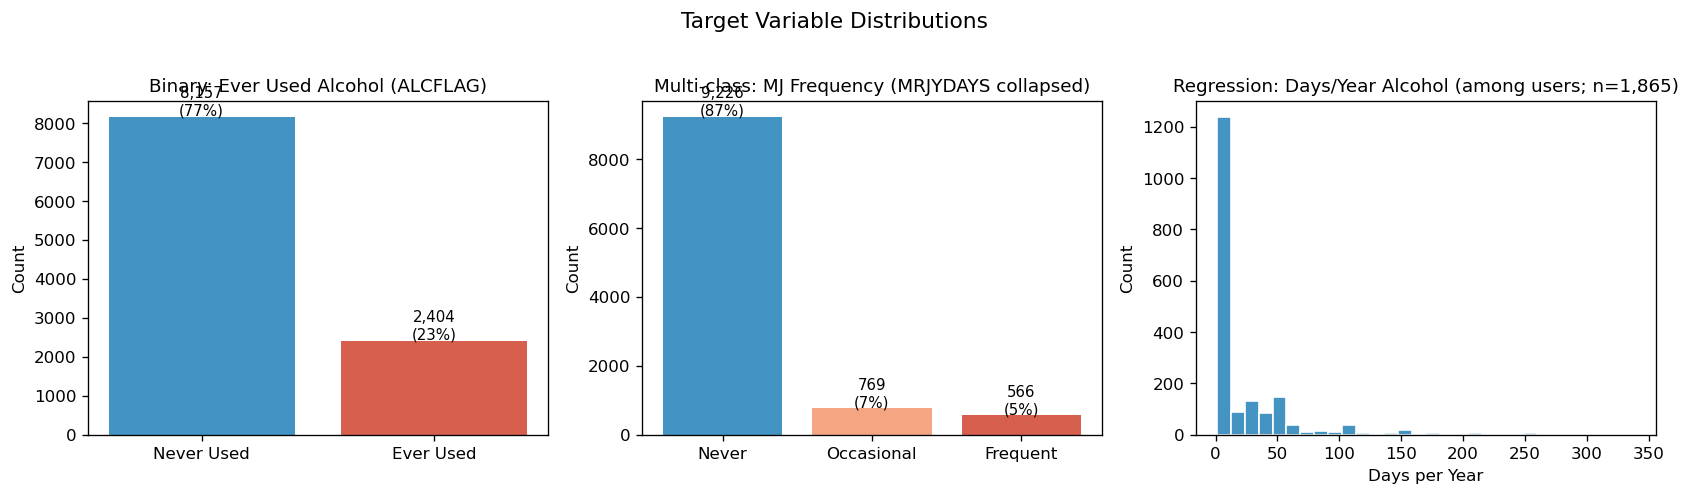

Saved: fig_eda_targets.png


In [9]:
# ── EDA summary figure ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Target 1 – ALCFLAG
vc1 = df['ALCFLAG'].value_counts().sort_index()
axes[0].bar(['Never Used', 'Ever Used'], vc1.values, color=['#4393c3', '#d6604d'])
axes[0].set_title('Binary: Ever Used Alcohol (ALCFLAG)', fontsize=11)
axes[0].set_ylabel('Count')
for i, v in enumerate(vc1.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(df):.0%})', ha='center', fontsize=9)

# Target 2 – MRJ3CLASS
vc2 = df['MRJ3CLASS'].value_counts().sort_index()
axes[1].bar(['Never', 'Occasional', 'Frequent'], vc2.values,
            color=['#4393c3', '#f4a582', '#d6604d'])
axes[1].set_title('Multi-class: MJ Frequency (MRJYDAYS collapsed)', fontsize=11)
axes[1].set_ylabel('Count')
for i, v in enumerate(vc2.values):
    axes[1].text(i, v + 50, f'{v:,}\n({v/len(df):.0%})', ha='center', fontsize=9)

# Target 3 – IRALCFY
alc_nonzero = df_reg[df_reg['IRALCFY'] > 0]['IRALCFY']
axes[2].hist(alc_nonzero, bins=30, color='#4393c3', edgecolor='white')
axes[2].set_title(f'Regression: Days/Year Alcohol (among users; n={len(alc_nonzero):,})', fontsize=11)
axes[2].set_xlabel('Days per Year')
axes[2].set_ylabel('Count')

plt.suptitle('Target Variable Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_eda_targets.png', bbox_inches='tight')
plt.show()
print("Saved: fig_eda_targets.png")


---
## Problem 1: Binary Classification - Ever Used Alcohol (ALCFLAG)

Models Used: Single Decision Tree -> Random Forest -> AdaBoost
Evaluation Approach: Accuracy, ROC AUC, Classification Report, Confusion Matrix


In [10]:
# ── Train/test split (stratified) ────────────────────────────────────────────
X_bin = df[feature_cols]
y_bin = df['ALCFLAG']

X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_bin, y_bin, test_size=0.20, stratify=y_bin, random_state=SEED)
print(f"Train: {len(X_tr_b):,}  |  Test: {len(X_te_b):,}")
print(f"Positive rate  →  Train: {y_tr_b.mean():.1%}  |  Test: {y_te_b.mean():.1%}")


Train: 8,448  |  Test: 2,113
Positive rate  →  Train: 22.8%  |  Test: 22.8%


### Single Decision Tree (Binary)

Best max_depth (3-fold CV ROC AUC): 5  →  AUC = 0.788


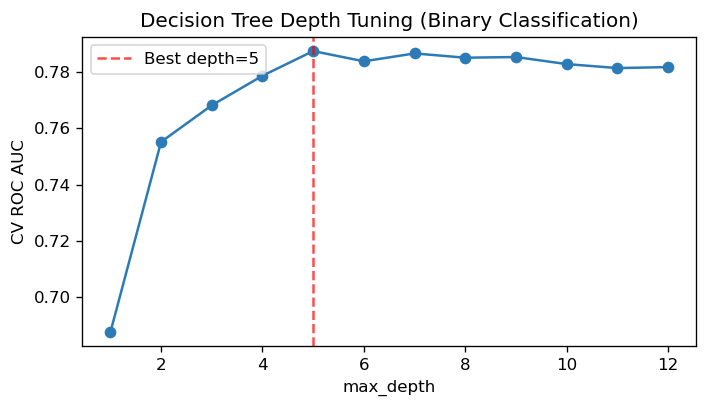

In [11]:
# ── Hyperparameter tuning: max_depth ─────────────────────────────────────────
depth_range = range(1, 13)
cv_auc = []
for d in depth_range:
    dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                min_samples_leaf=30, random_state=SEED)
    scores = cross_val_score(dt, X_tr_b, y_tr_b, cv=3, scoring='roc_auc')
    cv_auc.append(scores.mean())

best_depth_b = depth_range[int(np.argmax(cv_auc))]
print(f"Best max_depth (3-fold CV ROC AUC): {best_depth_b}  →  AUC = {max(cv_auc):.3f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(depth_range, cv_auc, 'o-', color='#2c7bb6')
ax.axvline(best_depth_b, color='red', linestyle='--', alpha=0.7, label=f'Best depth={best_depth_b}')
ax.set_xlabel('max_depth'); ax.set_ylabel('CV ROC AUC')
ax.set_title('Decision Tree Depth Tuning (Binary Classification)')
ax.legend(); plt.tight_layout()
plt.savefig('fig_bin_dt_tuning.png', bbox_inches='tight')
plt.show()


In [12]:
# ── Fit best single DT ────────────────────────────────────────────────────────
dt_bin = DecisionTreeClassifier(
    max_depth=best_depth_b,
    criterion='gini',
    class_weight='balanced',
    min_samples_leaf=30,
    random_state=SEED
)
dt_bin.fit(X_tr_b, y_tr_b)

y_pred_dt_b  = dt_bin.predict(X_te_b)
y_proba_dt_b = dt_bin.predict_proba(X_te_b)[:, 1]

print("── Single DT ───────────────────────────────────")
print(f"  Accuracy : {accuracy_score(y_te_b, y_pred_dt_b):.3f}")
print(f"  ROC AUC  : {roc_auc_score(y_te_b, y_proba_dt_b):.3f}")
print()
print(classification_report(y_te_b, y_pred_dt_b,
      target_names=['Never Used', 'Ever Used']))


── Single DT ───────────────────────────────────
  Accuracy : 0.759
  ROC AUC  : 0.768

              precision    recall  f1-score   support

  Never Used       0.88      0.79      0.84      1632
   Ever Used       0.48      0.64      0.55       481

    accuracy                           0.76      2113
   macro avg       0.68      0.72      0.69      2113
weighted avg       0.79      0.76      0.77      2113



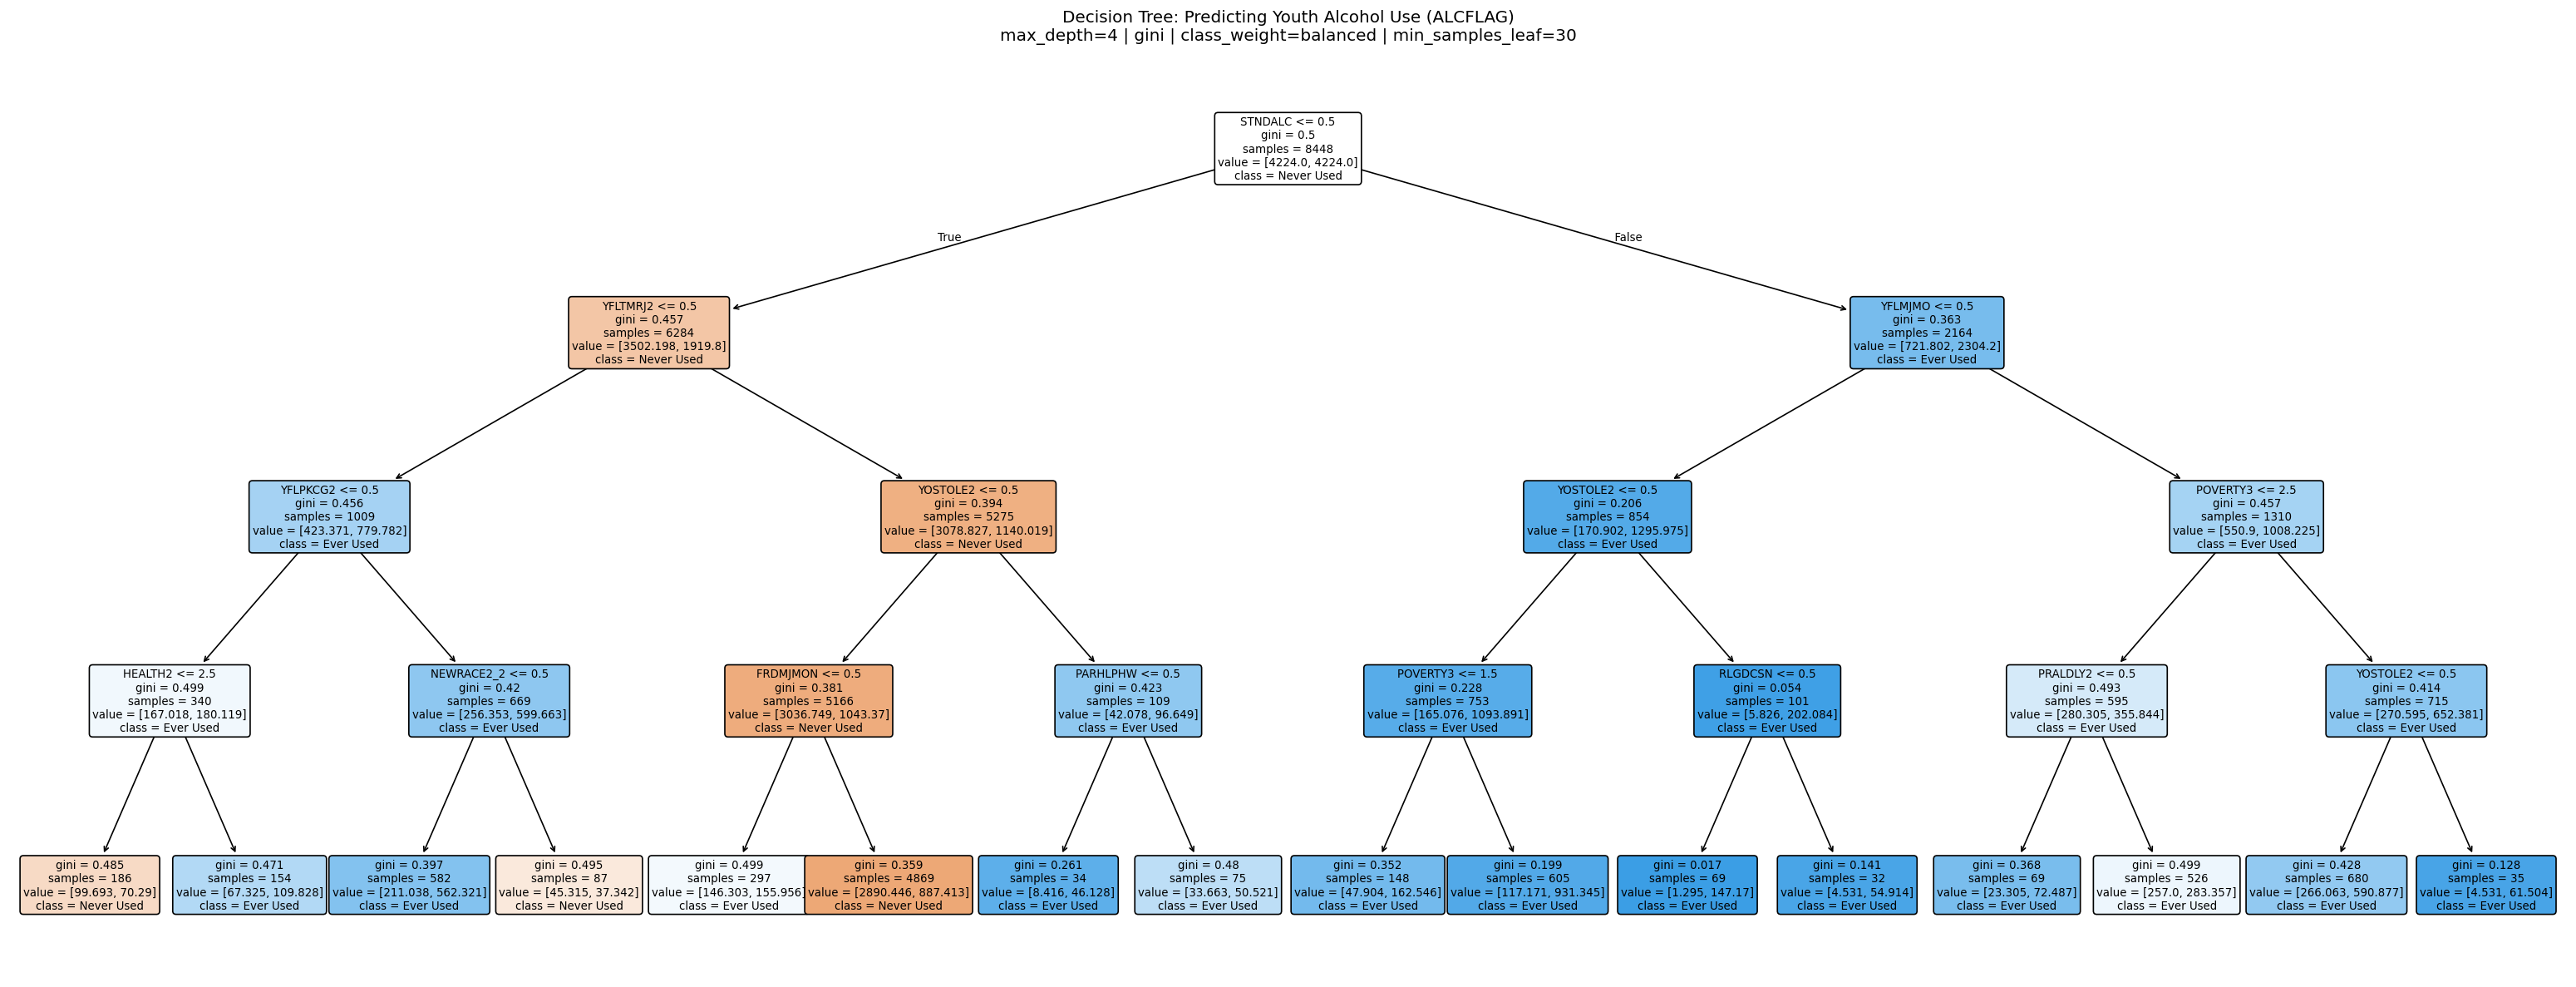


Text representation (depth=4 display tree):
|--- STNDALC <= 0.50
|   |--- YFLTMRJ2 <= 0.50
|   |   |--- YFLPKCG2 <= 0.50
|   |   |   |--- HEALTH2 <= 2.50
|   |   |   |   |--- class: 0
|   |   |   |--- HEALTH2 >  2.50
|   |   |   |   |--- class: 1
|   |   |--- YFLPKCG2 >  0.50
|   |   |   |--- NEWRACE2_2 <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- NEWRACE2_2 >  0.50
|   |   |   |   |--- class: 0
|   |--- YFLTMRJ2 >  0.50
|   |   |--- YOSTOLE2 <= 0.50
|   |   |   |--- FRDMJMON <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- FRDMJMON >  0.50
|   |   |   |   |--- class: 0
|   |   |--- YOSTOLE2 >  0.50
|   |   |   |--- PARHLPHW <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- PARHLPHW >  0.50
|   |   |   |   |--- class: 1
|--- STNDALC >  0.50
|   |--- YFLMJMO <= 0.50
|   |   |--- YOSTOLE2 <= 0.50
|   |   |   |--- POVERTY3 <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- POVERTY3 >  1.50
|   |   |   |   |--- class: 1
|   |   |--- YOSTOLE2 >  0.50
|   |   |   |-

In [13]:
# ── Tree visualization (depth=4 for readability) ─────────────────────────────
# Python makes a mess of these trees if not managed properly.
dt_vis = DecisionTreeClassifier(
    max_depth=4, criterion='gini', class_weight='balanced',
    min_samples_leaf=30, random_state=SEED)
dt_vis.fit(X_tr_b, y_tr_b)

fig_tree, ax_tree = plt.subplots(figsize=(26, 10))
plot_tree(dt_vis, feature_names=feature_cols,
          class_names=['Never Used', 'Ever Used'],
          filled=True, rounded=True, fontsize=8, ax=ax_tree,
          impurity=True, proportion=False)
ax_tree.set_title(
    "Decision Tree: Predicting Youth Alcohol Use (ALCFLAG)\n"
    "max_depth=4 | gini | class_weight=balanced | min_samples_leaf=30",
    fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('fig_bin_dt_tree.png', bbox_inches='tight', dpi=140)
plt.show()
print("\nText representation (depth=4 display tree):")
print(export_text(dt_vis, feature_names=feature_cols))


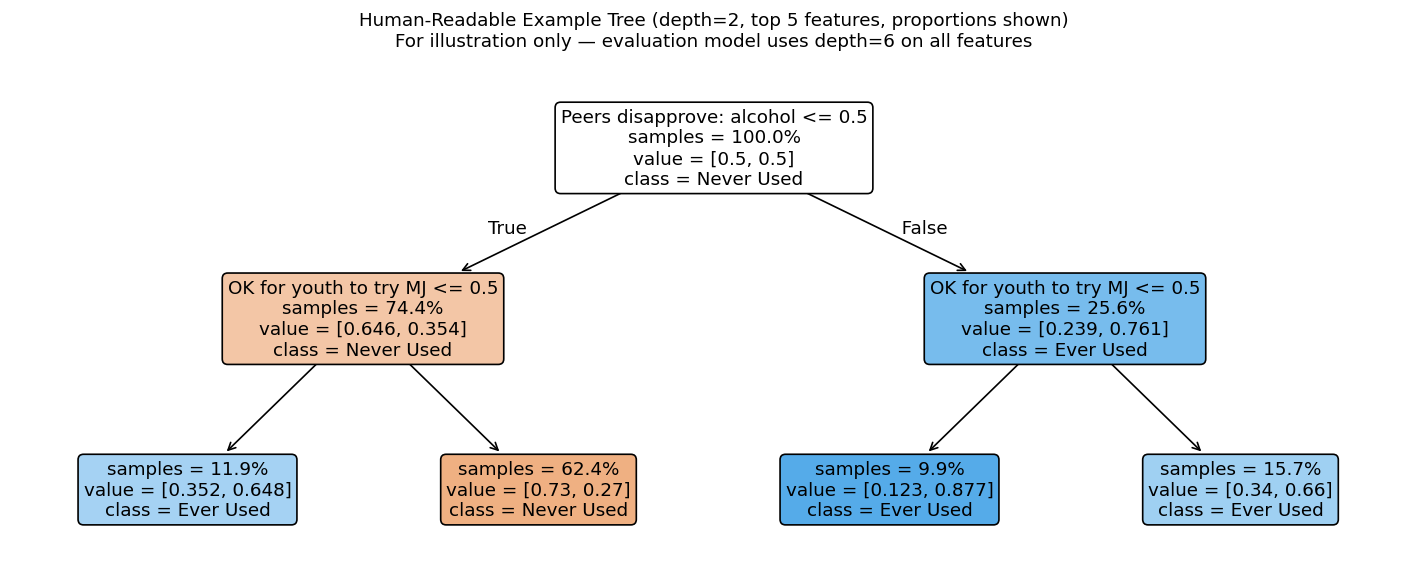

Saved: fig_readable_tree.png
|--- Peers disapprove: alcohol <= 0.50
|   |--- OK for youth to try MJ <= 0.50
|   |   |--- class: 1
|   |--- OK for youth to try MJ >  0.50
|   |   |--- class: 0
|--- Peers disapprove: alcohol >  0.50
|   |--- OK for youth to try MJ <= 0.50
|   |   |--- class: 1
|   |--- OK for youth to try MJ >  0.50
|   |   |--- class: 1



In [14]:
# ── Human-readable example tree (depth=2) ────────────────────────────────────
# The full predictive tree (depth=6) is too complex for visual interpretation.
# This cell fits a separate shallow tree on the top 5 features for the sole
# purpose of clear human-readable illustration. It is NOT used for evaluation.
top_features = ['STNDALC', 'YFLTMRJ2', 'FRDMJMON', 'PRALDLY2', 'YOSTOLE2']
dt_readable = DecisionTreeClassifier(
    max_depth=2, criterion='gini',
    class_weight='balanced', min_samples_leaf=30,
    random_state=SEED
)
dt_readable.fit(X_tr_b[top_features], y_tr_b)

fig_rd, ax_rd = plt.subplots(figsize=(12, 5))
plot_tree(
    dt_readable,
    feature_names=[label(f) for f in top_features],
    class_names=['Never Used', 'Ever Used'],
    filled=True, rounded=True, fontsize=11,
    ax=ax_rd, impurity=False, proportion=True
)
ax_rd.set_title(
    'Human-Readable Example Tree (depth=2, top 5 features, proportions shown)\n'
    'For illustration only — evaluation model uses depth=6 on all features',
    fontsize=11, pad=10
)
plt.tight_layout()
plt.savefig('fig_readable_tree.png', dpi=140, bbox_inches='tight')
plt.show()
print("Saved: fig_readable_tree.png")
print(export_text(dt_readable, feature_names=[label(f) for f in top_features]))


### Random Forest (Binary)

In [15]:
# ── GridSearchCV tuning: Random Forest ───────────────────────────────────────
# Parameters tuned and rationale:
#   n_estimators    — more trees reduces variance; diminishing returns ~300
#   max_depth       — controls individual tree complexity
#   max_features    — fraction of features sampled per split (key RF regularizer)
#   min_samples_leaf — min leaf size; larger = smoother predictions, less overfit
rf_param_grid = {
    'n_estimators':     [100, 200],
    'max_depth':        [4, 6],
    'max_features':     ['sqrt'],
    'min_samples_leaf': [20, 50],
}
rf_gs = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=SEED),
    rf_param_grid, cv=2, scoring='roc_auc', n_jobs=-1, verbose=0
)
rf_gs.fit(X_tr_b, y_tr_b)
print(f"Best RF params : {rf_gs.best_params_}")
print(f"Best CV AUC    : {rf_gs.best_score_:.3f}")


Best RF params : {'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'n_estimators': 200}
Best CV AUC    : 0.815


── Random Forest ───────────────────────────────
  Accuracy : 0.748
  ROC AUC  : 0.797

              precision    recall  f1-score   support

  Never Used       0.89      0.77      0.82      1632
   Ever Used       0.46      0.68      0.55       481

    accuracy                           0.75      2113
   macro avg       0.68      0.73      0.69      2113
weighted avg       0.79      0.75      0.76      2113



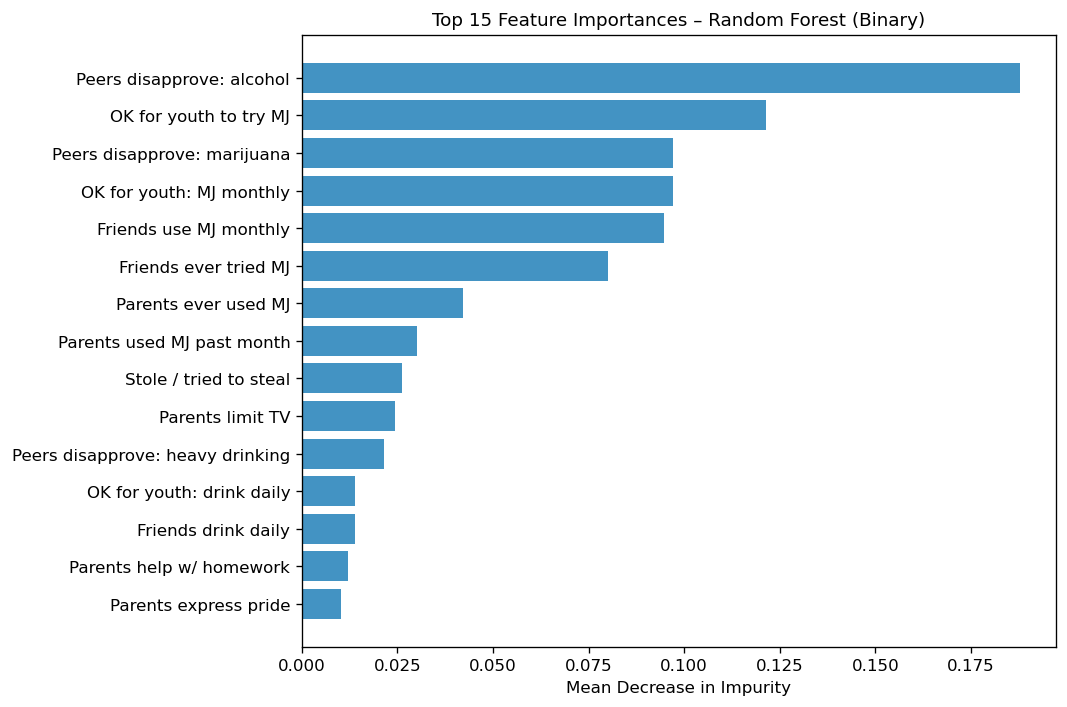

In [16]:
rf_bin = rf_gs.best_estimator_
y_pred_rf_b  = rf_bin.predict(X_te_b)
y_proba_rf_b = rf_bin.predict_proba(X_te_b)[:, 1]

print("── Random Forest ───────────────────────────────")
print(f"  Accuracy : {accuracy_score(y_te_b, y_pred_rf_b):.3f}")
print(f"  ROC AUC  : {roc_auc_score(y_te_b, y_proba_rf_b):.3f}")
print()
print(classification_report(y_te_b, y_pred_rf_b,
      target_names=['Never Used', 'Ever Used']))

# Feature importance with readable labels
imp_rf = (pd.DataFrame({'feature': feature_cols,
                         'importance': rf_bin.feature_importances_})
            .sort_values('importance', ascending=False)
            .head(15).reset_index(drop=True))
fig_imp, ax_imp = plt.subplots(figsize=(9, 6))
ax_imp.barh([label(f) for f in imp_rf['feature'][::-1]],
             imp_rf['importance'][::-1], color='#4393c3')
ax_imp.set_xlabel('Mean Decrease in Impurity')
ax_imp.set_title('Top 15 Feature Importances – Random Forest (Binary)', fontsize=11)
plt.tight_layout()
plt.savefig('fig_bin_rf_importance.png', dpi=140, bbox_inches='tight')
plt.show()


### AdaBoost (Binary)

In [17]:
# ── GridSearchCV tuning: AdaBoost ─────────────────────────────────────────────
# Parameters tuned:
#   n_estimators  — number of sequential weak learners
#   learning_rate — shrinks each learner's contribution; trades off with n_estimators
ada_param_grid = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.1, 0.5],
}
ada_gs = GridSearchCV(
    AdaBoostClassifier(random_state=SEED),
    ada_param_grid, cv=2, scoring='roc_auc', n_jobs=-1, verbose=0
)
ada_gs.fit(X_tr_b, y_tr_b)
print(f"Best AdaBoost params: {ada_gs.best_params_}")
print(f"Best CV AUC         : {ada_gs.best_score_:.3f}")


Best AdaBoost params: {'learning_rate': 0.5, 'n_estimators': 200}
Best CV AUC         : 0.813


In [18]:
ada_bin = ada_gs.best_estimator_
y_pred_ada_b  = ada_bin.predict(X_te_b)
y_proba_ada_b = ada_bin.predict_proba(X_te_b)[:, 1]

print("── AdaBoost ────────────────────────────────────")
print(f"  Accuracy : {accuracy_score(y_te_b, y_pred_ada_b):.3f}")
print(f"  ROC AUC  : {roc_auc_score(y_te_b, y_proba_ada_b):.3f}")
print()
print(classification_report(y_te_b, y_pred_ada_b,
      target_names=['Never Used', 'Ever Used']))


── AdaBoost ────────────────────────────────────
  Accuracy : 0.811
  ROC AUC  : 0.795

              precision    recall  f1-score   support

  Never Used       0.83      0.95      0.89      1632
   Ever Used       0.66      0.35      0.46       481

    accuracy                           0.81      2113
   macro avg       0.75      0.65      0.67      2113
weighted avg       0.79      0.81      0.79      2113



### Binary Classification — Model Comparison

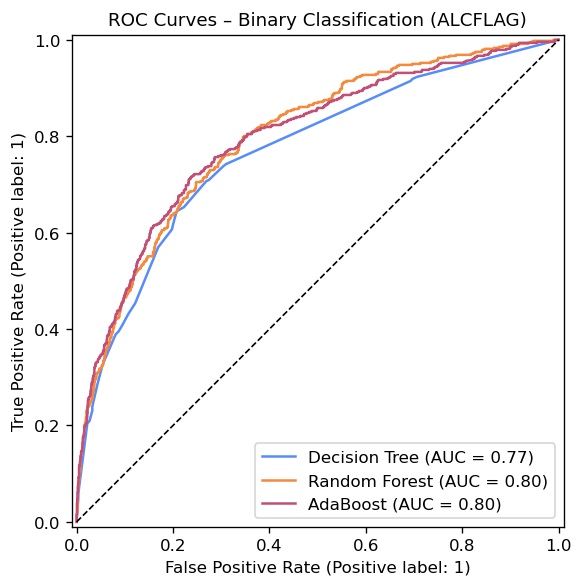


── Binary Classification Summary ───────────────
        Model  Accuracy  ROC AUC
Decision Tree     0.759    0.768
Random Forest     0.748    0.797
     AdaBoost     0.811    0.795


In [19]:
# ── ROC curves comparison ─────────────────────────────────────────────────────
fig_roc, ax_roc = plt.subplots(figsize=(6, 5))
for name, proba in [('Decision Tree', y_proba_dt_b),
                     ('Random Forest', y_proba_rf_b),
                     ('AdaBoost',      y_proba_ada_b)]:
    RocCurveDisplay.from_predictions(y_te_b, proba, ax=ax_roc, name=name)
ax_roc.plot([0,1],[0,1],'k--', lw=1)
ax_roc.set_title('ROC Curves – Binary Classification (ALCFLAG)', fontsize=11)
plt.tight_layout()
plt.savefig('fig_bin_roc_compare.png', bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
bin_summary = pd.DataFrame({
    'Model':    ['Decision Tree', 'Random Forest', 'AdaBoost'],
    'Accuracy': [accuracy_score(y_te_b, y_pred_dt_b),
                 accuracy_score(y_te_b, y_pred_rf_b),
                 accuracy_score(y_te_b, y_pred_ada_b)],
    'ROC AUC':  [roc_auc_score(y_te_b, y_proba_dt_b),
                 roc_auc_score(y_te_b, y_proba_rf_b),
                 roc_auc_score(y_te_b, y_proba_ada_b)],
}).round(3)
print("\n── Binary Classification Summary ───────────────")
print(bin_summary.to_string(index=False))


---
## Problem 2: Multi-class Classification - Marijuana Use Frequency (MRJ3CLASS)

Classes of Use: 0 = Never (n≈9,226) · 1 = Occasional, 1–49 days/yr (n≈769) · 2 = Frequent, 50+ days/yr (n≈566)
Models Used: Single Decision Tree -> Gradient Boosting


In [20]:
X_mc = df[feature_cols]
y_mc = df['MRJ3CLASS']

X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X_mc, y_mc, test_size=0.20, stratify=y_mc, random_state=SEED)
print(f"Train: {len(X_tr_m):,}  |  Test: {len(X_te_m):,}")
print("Class distribution (test):")
print(y_te_m.value_counts().sort_index().rename({0:'Never',1:'Occasional',2:'Frequent'}).to_string())


Train: 8,448  |  Test: 2,113
Class distribution (test):
MRJ3CLASS
Never         1846
Occasional     154
Frequent       113


### Single Decision Tree (Multi-class)

Best max_depth (3-fold CV macro-F1): 4  →  F1 = 0.452


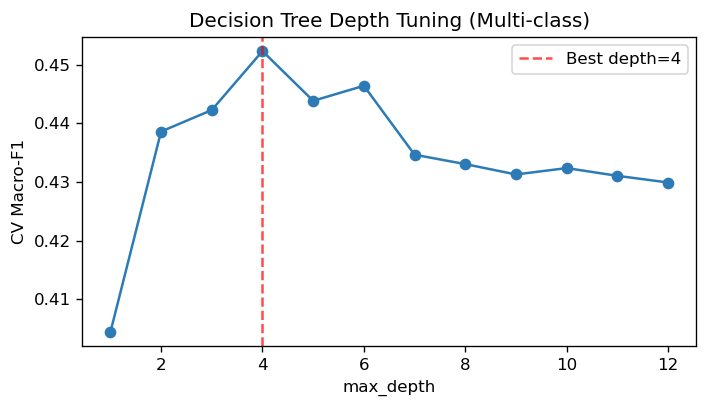

In [21]:
# Tune max_depth using macro-averaged F1
from sklearn.metrics import f1_score

depth_range_m = range(1, 13)
cv_f1_m = []
for d in depth_range_m:
    dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                min_samples_leaf=30, random_state=SEED)
    scores = cross_val_score(dt, X_tr_m, y_tr_m, cv=3, scoring='f1_macro')
    cv_f1_m.append(scores.mean())

best_depth_m = depth_range_m[int(np.argmax(cv_f1_m))]
print(f"Best max_depth (3-fold CV macro-F1): {best_depth_m}  →  F1 = {max(cv_f1_m):.3f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(depth_range_m, cv_f1_m, 'o-', color='#2c7bb6')
ax.axvline(best_depth_m, color='red', linestyle='--', alpha=0.7,
           label=f'Best depth={best_depth_m}')
ax.set_xlabel('max_depth'); ax.set_ylabel('CV Macro-F1')
ax.set_title('Decision Tree Depth Tuning (Multi-class)')
ax.legend(); plt.tight_layout()
plt.savefig('fig_mc_dt_tuning.png', bbox_inches='tight')
plt.show()


In [22]:
dt_mc = DecisionTreeClassifier(
    max_depth=best_depth_m, criterion='gini',
    class_weight='balanced', min_samples_leaf=30, random_state=SEED)
dt_mc.fit(X_tr_m, y_tr_m)
y_pred_dt_m = dt_mc.predict(X_te_m)

print("── Single DT (multi-class) ──────────────────────")
print(f"  Accuracy : {accuracy_score(y_te_m, y_pred_dt_m):.3f}")
print()
print(classification_report(y_te_m, y_pred_dt_m,
      target_names=['Never', 'Occasional', 'Frequent']))


── Single DT (multi-class) ──────────────────────
  Accuracy : 0.665

              precision    recall  f1-score   support

       Never       0.98      0.69      0.81      1846
  Occasional       0.14      0.51      0.22       154
    Frequent       0.22      0.50      0.31       113

    accuracy                           0.66      2113
   macro avg       0.45      0.57      0.45      2113
weighted avg       0.88      0.66      0.74      2113



### Gradient Boosting (Multi-class)

In [23]:
# ── GridSearchCV tuning: Gradient Boosting (multi-class) ─────────────────────
# Parameters tuned:
#   n_estimators    — number of boosting stages
#   learning_rate   — shrinkage per stage (lower = more stages needed)
#   max_depth       — depth of each weak learner
#   subsample       — fraction of training samples per stage (stochastic GB)
#   min_samples_split — minimum samples required to split a node

gb_param_grid = {
    'n_estimators':      [100, 200],
    'learning_rate':     [0.05, 0.1],
    'max_depth':         [3, 5],
    'subsample':         [0.8, 1.0],
    'min_samples_split': [2, 10],
}
gb_gs = GridSearchCV(
    GradientBoostingClassifier(random_state=SEED),
    gb_param_grid, cv=2, scoring='f1_macro', n_jobs=-1, verbose=0
)
gb_gs.fit(X_tr_m, y_tr_m)
print(f"Best GBM params  : {gb_gs.best_params_}")
print(f"Best CV macro-F1 : {gb_gs.best_score_:.3f}")


Best GBM params  : {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 1.0}
Best CV macro-F1 : 0.508


In [24]:
gb_mc = gb_gs.best_estimator_
y_pred_gb_m = gb_mc.predict(X_te_m)

print("── Gradient Boosting (multi-class) ──────────────")
print(f"  Accuracy : {accuracy_score(y_te_m, y_pred_gb_m):.3f}")
print()
print(classification_report(y_te_m, y_pred_gb_m,
      target_names=['Never', 'Occasional', 'Frequent']))


── Gradient Boosting (multi-class) ──────────────
  Accuracy : 0.876

              precision    recall  f1-score   support

       Never       0.91      0.97      0.94      1846
  Occasional       0.27      0.13      0.18       154
    Frequent       0.49      0.35      0.41       113

    accuracy                           0.88      2113
   macro avg       0.56      0.48      0.51      2113
weighted avg       0.85      0.88      0.86      2113



### Multi-class Comparison

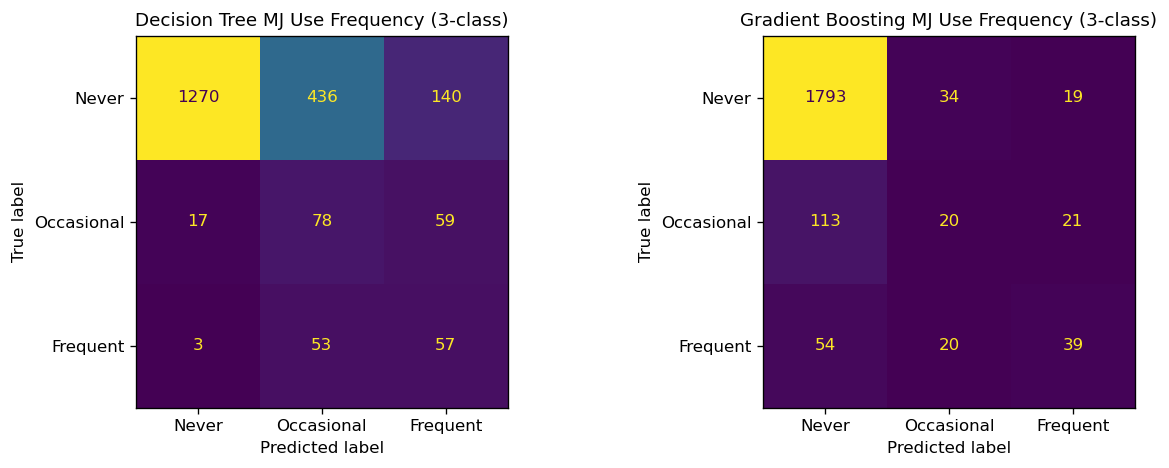


── Multi-class Summary ─────────────────────────
            Model  Accuracy  Macro F1
    Decision Tree     0.665     0.445
Gradient Boosting     0.876     0.508


In [25]:
fig_cm, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, pred, title in zip(axes,
                            [y_pred_dt_m, y_pred_gb_m],
                            ['Decision Tree', 'Gradient Boosting']):
    ConfusionMatrixDisplay.from_predictions(
        y_te_m, pred,
        display_labels=['Never', 'Occasional', 'Frequent'],
        colorbar=False, ax=ax)
    ax.set_title(f'{title} MJ Use Frequency (3-class)', fontsize=11)
plt.tight_layout()
plt.savefig('fig_mc_cm_compare.png', bbox_inches='tight')
plt.show()

mc_summary = pd.DataFrame({
    'Model':       ['Decision Tree', 'Gradient Boosting'],
    'Accuracy':    [accuracy_score(y_te_m, y_pred_dt_m),
                    accuracy_score(y_te_m, y_pred_gb_m)],
    'Macro F1':    [f1_score(y_te_m, y_pred_dt_m, average='macro'),
                    f1_score(y_te_m, y_pred_gb_m, average='macro')],
}).round(3)
print("\n── Multi-class Summary ─────────────────────────")
print(mc_summary.to_string(index=False))


---
## Problem 3: Regression - Days per Year of Alcohol Use (IRALCFY)

Target: `IRALCFY` — integer days/year, 0–365
(991="never used" recoded to 0; 993="refused" dropped, n=539)  
Models Used: Single Decision Tree Regressor -> Bagging Regressor -> Gradient Boosting Regressor


In [26]:
X_reg = df_reg[feature_cols]
y_reg = df_reg['IRALCFY']

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=SEED)
print(f"Train: {len(X_tr_r):,}  |  Test: {len(X_te_r):,}")
print(f"Target mean: {y_tr_r.mean():.1f} days/yr  |  std: {y_tr_r.std():.1f}")


Train: 8,017  |  Test: 2,005
Target mean: 4.1 days/yr  |  std: 19.6


### Single Decision Tree (Regression)

Best max_depth (3-fold CV RMSE): 3  →  RMSE = 18.68 days/yr


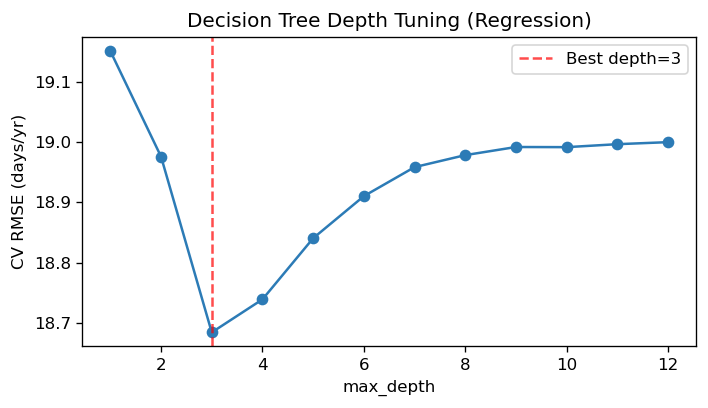

In [27]:
depth_range_r = range(1, 13)
cv_rmse_r = []
for d in depth_range_r:
    dt = DecisionTreeRegressor(max_depth=d, min_samples_leaf=30, random_state=SEED)
    scores = cross_val_score(dt, X_tr_r, y_tr_r, cv=3,
                             scoring='neg_mean_squared_error')
    cv_rmse_r.append(np.sqrt(-scores.mean()))

best_depth_r = depth_range_r[int(np.argmin(cv_rmse_r))]
print(f"Best max_depth (3-fold CV RMSE): {best_depth_r}  →  RMSE = {min(cv_rmse_r):.2f} days/yr")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(depth_range_r, cv_rmse_r, 'o-', color='#2c7bb6')
ax.axvline(best_depth_r, color='red', linestyle='--', alpha=0.7,
           label=f'Best depth={best_depth_r}')
ax.set_xlabel('max_depth'); ax.set_ylabel('CV RMSE (days/yr)')
ax.set_title('Decision Tree Depth Tuning (Regression)')
ax.legend(); plt.tight_layout()
plt.savefig('fig_reg_dt_tuning.png', bbox_inches='tight')
plt.show()


In [28]:
dt_reg = DecisionTreeRegressor(
    max_depth=best_depth_r, min_samples_leaf=30, random_state=SEED)
dt_reg.fit(X_tr_r, y_tr_r)
y_pred_dt_r = dt_reg.predict(X_te_r)

rmse_dt_r = np.sqrt(mean_squared_error(y_te_r, y_pred_dt_r))
mae_dt_r  = mean_absolute_error(y_te_r, y_pred_dt_r)
r2_dt_r   = r2_score(y_te_r, y_pred_dt_r)

print("── Decision Tree Regressor ──────────────────────")
print(f"  RMSE : {rmse_dt_r:.2f} days/yr")
print(f"  MAE  : {mae_dt_r:.2f} days/yr")
print(f"  R²   : {r2_dt_r:.3f}")


── Decision Tree Regressor ──────────────────────
  RMSE : 18.09 days/yr
  MAE  : 6.19 days/yr
  R²   : 0.069


### Bagging Regressor

In [29]:
# ── GridSearchCV tuning: Bagging Regressor ───────────────────────────────────
# Parameters tuned:
#   n_estimators — number of base estimators
#   max_features — fraction of features sampled per estimator
#   max_samples  — fraction of training samples per estimator
bag_param_grid = {
    'n_estimators': [50, 100],
    'max_features': [0.5, 1.0],
    'max_samples':  [0.8, 1.0],
}
bag_gs = GridSearchCV(
    BaggingRegressor(
        estimator=DecisionTreeRegressor(max_depth=best_depth_r,
                                        min_samples_leaf=30,
                                        random_state=SEED),
        random_state=SEED),
    bag_param_grid, cv=2, scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=0
)
bag_gs.fit(X_tr_r, y_tr_r)
print(f"Best Bagging params : {bag_gs.best_params_}")
print(f"Best CV RMSE        : {np.sqrt(-bag_gs.best_score_):.2f} days/yr")


Best Bagging params : {'max_features': 0.5, 'max_samples': 1.0, 'n_estimators': 100}
Best CV RMSE        : 18.52 days/yr


In [30]:
bag_reg = bag_gs.best_estimator_
y_pred_bag_r = bag_reg.predict(X_te_r)

rmse_bag_r = np.sqrt(mean_squared_error(y_te_r, y_pred_bag_r))
mae_bag_r  = mean_absolute_error(y_te_r, y_pred_bag_r)
r2_bag_r   = r2_score(y_te_r, y_pred_bag_r)

print("── Bagging Regressor ───────────────────────────")
print(f"  RMSE : {rmse_bag_r:.2f} days/yr")
print(f"  MAE  : {mae_bag_r:.2f} days/yr")
print(f"  R²   : {r2_bag_r:.3f}")


── Bagging Regressor ───────────────────────────
  RMSE : 17.53 days/yr
  MAE  : 6.11 days/yr
  R²   : 0.126


### Gradient Boosting Regressor

In [31]:
# ── GridSearchCV tuning: Gradient Boosting Regressor ─────────────────────────
# Parameters tuned:
#   n_estimators, learning_rate, max_depth — same as classifier version
#   subsample       — stochastic GB; reduces overfitting on noisy targets
#   min_samples_split — node-split regularizer

gbr_param_grid = {
    'n_estimators':      [100, 200],
    'learning_rate':     [0.05, 0.1],
    'max_depth':         [3, 5],
    'subsample':         [0.8, 1.0],
    'min_samples_split': [2, 10],
}

gbr_gs = GridSearchCV(
    GradientBoostingRegressor(random_state=SEED),
    gbr_param_grid, cv=2, scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=0
)
gbr_gs.fit(X_tr_r, y_tr_r)
print(f"Best GBR params: {gbr_gs.best_params_}")
print(f"Best CV RMSE   : {np.sqrt(-gbr_gs.best_score_):.2f} days/yr")


Best GBR params: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 100, 'subsample': 0.8}
Best CV RMSE   : 18.36 days/yr


In [32]:
gbr_reg = gbr_gs.best_estimator_
y_pred_gbr_r = gbr_reg.predict(X_te_r)

rmse_gbr_r = np.sqrt(mean_squared_error(y_te_r, y_pred_gbr_r))
mae_gbr_r  = mean_absolute_error(y_te_r, y_pred_gbr_r)
r2_gbr_r   = r2_score(y_te_r, y_pred_gbr_r)

print("── Gradient Boosting Regressor ─────────────────")
print(f"  RMSE : {rmse_gbr_r:.2f} days/yr")
print(f"  MAE  : {mae_gbr_r:.2f} days/yr")
print(f"  R²   : {r2_gbr_r:.3f}")


── Gradient Boosting Regressor ─────────────────
  RMSE : 18.11 days/yr
  MAE  : 5.97 days/yr
  R²   : 0.068


### Regression — Model Comparison

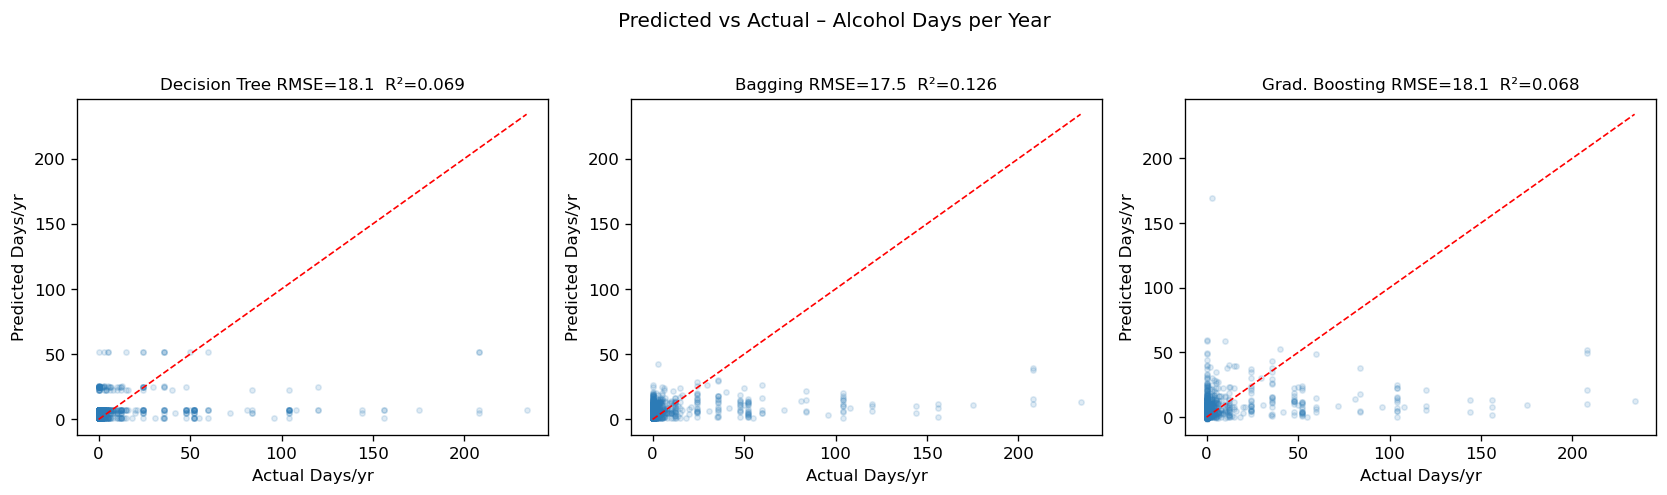


── Regression Summary ──────────────────────────
         Model   RMSE   MAE    R²
 Decision Tree 18.094 6.193 0.069
       Bagging 17.525 6.111 0.126
Grad. Boosting 18.107 5.973 0.068


In [33]:
# Predicted vs actual scatter (all three models)
fig_pva, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, pred, title in zip(axes,
                            [y_pred_dt_r, y_pred_bag_r, y_pred_gbr_r],
                            ['Decision Tree', 'Bagging', 'Grad. Boosting']):
    ax.scatter(y_te_r, pred, alpha=0.15, s=10, color='#2c7bb6')
    lim = max(y_te_r.max(), pred.max())
    ax.plot([0, lim], [0, lim], 'r--', lw=1)
    ax.set_xlabel('Actual Days/yr'); ax.set_ylabel('Predicted Days/yr')
    r2 = r2_score(y_te_r, pred)
    rmse = np.sqrt(mean_squared_error(y_te_r, pred))
    ax.set_title(f'{title} RMSE={rmse:.1f}  R²={r2:.3f}', fontsize=10)
plt.suptitle('Predicted vs Actual – Alcohol Days per Year', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig_reg_pva_compare.png', bbox_inches='tight')
plt.show()

reg_summary = pd.DataFrame({
    'Model': ['Decision Tree', 'Bagging', 'Grad. Boosting'],
    'RMSE':  [rmse_dt_r, rmse_bag_r, rmse_gbr_r],
    'MAE':   [mae_dt_r,  mae_bag_r,  mae_gbr_r],
    'R²':    [r2_dt_r,   r2_bag_r,   r2_gbr_r],
}).round(3)
print("\n── Regression Summary ──────────────────────────")
print(reg_summary.to_string(index=False))



## Tree Visualization with Feature Importance Table

In this section, we'll plot a tree plot paired with a feature importance table.
We use the best binary classification tree (depth=4 for readability) alongside
a ranked importance table so the two can be read together.


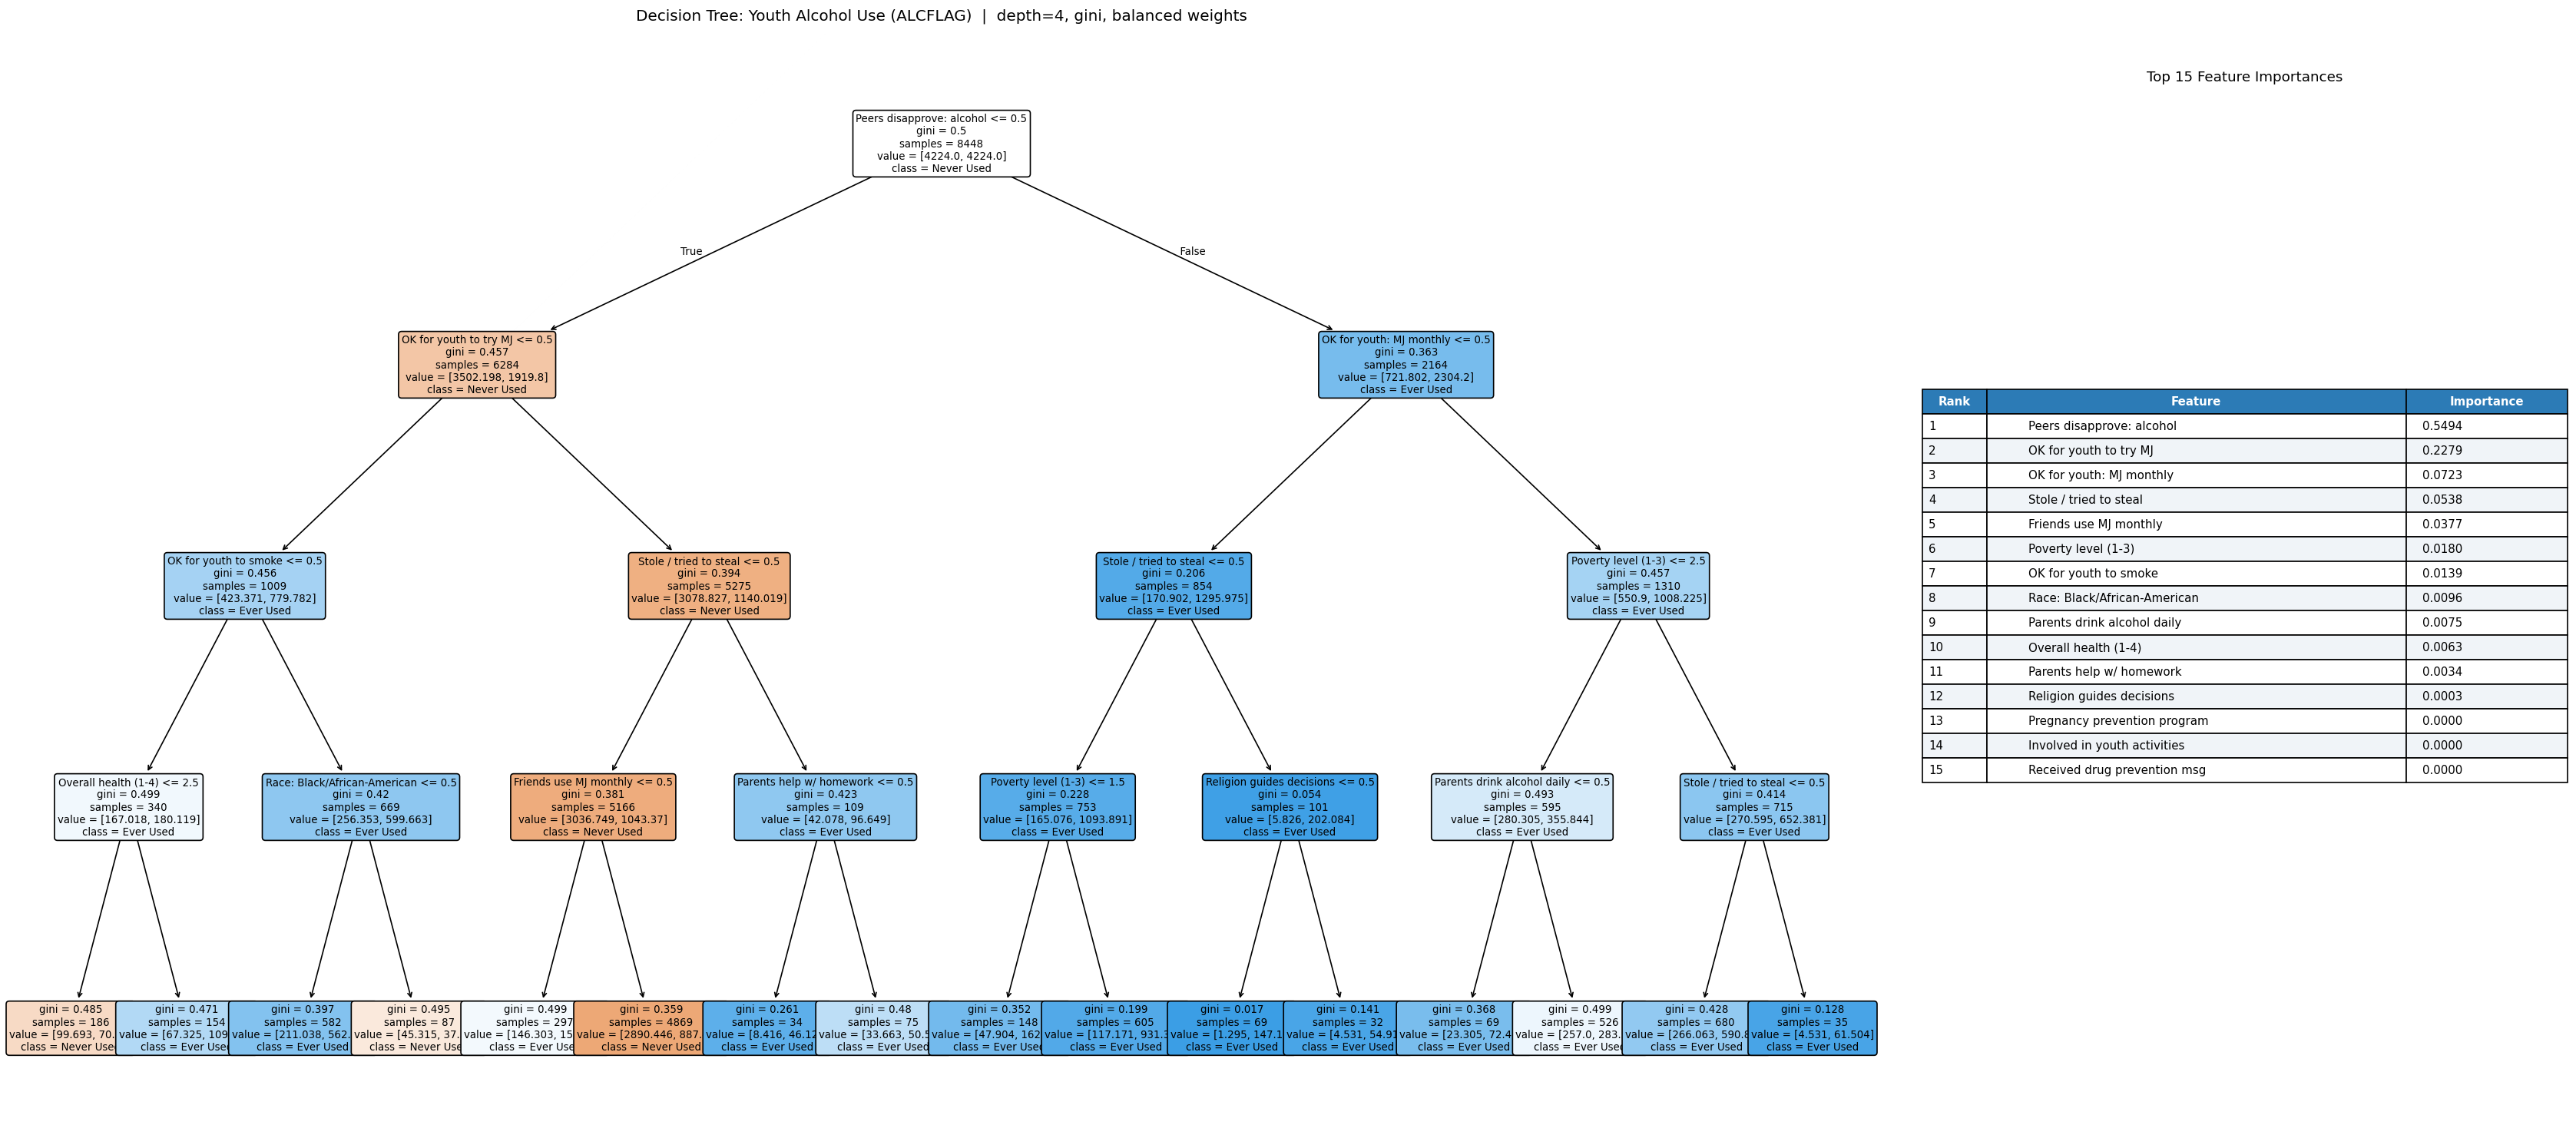

Saved: fig_tree_with_importance_table.png


In [34]:
# ── Figure: Tree diagram + feature importance table (side-by-side) ────────────
fig = plt.figure(figsize=(28, 12))
ax_tree = fig.add_axes([0.0, 0.0, 0.72, 1.0])
plot_tree(
    dt_vis,
    feature_names=[label(f) for f in feature_cols],
    class_names=['Never Used', 'Ever Used'],
    filled=True, rounded=True, fontsize=8,
    ax=ax_tree, impurity=True, proportion=False
)
ax_tree.set_title(
    'Decision Tree: Youth Alcohol Use (ALCFLAG)  |  depth=4, gini, balanced weights',
    fontsize=12, pad=10
)
ax_tbl = fig.add_axes([0.74, 0.05, 0.25, 0.90])
ax_tbl.axis('off')

imp_vis = (pd.DataFrame({'Feature': feature_cols,
                          'Importance': dt_vis.feature_importances_})
             .sort_values('Importance', ascending=False).head(15).reset_index(drop=True))
imp_vis['Rank'] = imp_vis.index + 1
imp_vis['Readable'] = imp_vis['Feature'].apply(label)
imp_vis['Importance'] = imp_vis['Importance'].map('{:.4f}'.format)

table_data = [['Rank', 'Feature', 'Importance']] +              imp_vis[['Rank', 'Readable', 'Importance']].values.tolist()
tbl = ax_tbl.table(cellText=table_data[1:], colLabels=table_data[0],
                    cellLoc='left', loc='center', colWidths=[0.10, 0.65, 0.25])
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.6)
for j in range(3):
    tbl[0, j].set_facecolor('#2c7bb6')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(table_data)):
    c = '#f0f4f8' if i % 2 == 0 else 'white'
    for j in range(3): tbl[i, j].set_facecolor(c)
ax_tbl.set_title('Top 15 Feature Importances', fontsize=11, pad=6)
plt.savefig('fig_tree_with_importance_table.png', dpi=140, bbox_inches='tight')
plt.show()
print("Saved: fig_tree_with_importance_table.png")



## Decision Path Trace

We trace one noteworthy path through the tree: a youth predicted as Ever Used Alcohol
who shows a pattern of permissive peer/self attitudes toward substances despite school
anti-alcohol norms.

The path is highlighted by re-drawing the tree and annotating the decision nodes
manually with the split logic and sample counts at each node.


In [35]:
# ── Trace the most populated "Ever Used" path through the depth-4 tree ────────
# We'll identify a real test-set example that follows an interesting path,
# then annotate its route through the tree.

from sklearn.tree import _tree

def get_decision_path_text(tree, feature_names, sample):
    """Returns a list of (feature, threshold, direction, node_id) for one sample."""
    tree_ = tree.tree_
    feature = tree_.feature
    threshold = tree_.threshold
    node_indicator = tree.decision_path(sample)
    node_ids = node_indicator.indices
    path = []
    for i, node_id in enumerate(node_ids[:-1]):
        feat_name = feature_names[feature[node_id]]
        thresh    = threshold[node_id]
        val       = sample[0, feature[node_id]]
        direction = '<=' if val <= thresh else '>'
        n_samples = tree_.n_node_samples[node_id]
        path.append({
            'node': node_id,
            'feature': feat_name,
            'threshold': thresh,
            'value': val,
            'direction': direction,
            'n_samples': n_samples
        })
    leaf_id = node_ids[-1]
    leaf_class = tree_.value[leaf_id].argmax()
    leaf_n = tree_.n_node_samples[leaf_id]
    return path, leaf_class, leaf_id, leaf_n

# Find a test-set youth predicted Ever Used via STNDALC→YFLTMRJ2 path
X_te_arr = X_te_b.values
ever_used_mask = (y_pred_dt_b == 1) & (y_te_b.values == 1)  # correctly predicted positives
candidates = np.where(ever_used_mask)[0]

# Pick the candidate whose path goes through STNDALC then YFLTMRJ2
chosen_idx = None
for idx in candidates:
    sample = X_te_arr[idx:idx+1]
    path, leaf_class, leaf_id, leaf_n = get_decision_path_text(dt_vis, feature_cols, sample)
    feat_names_in_path = [p['feature'] for p in path]
    if 'STNDALC' in feat_names_in_path and 'YFLTMRJ2' in feat_names_in_path:
        chosen_idx = idx
        break

if chosen_idx is None:
    chosen_idx = candidates[0]  # fallback

sample = X_te_arr[chosen_idx:chosen_idx+1]
path, leaf_class, leaf_id, leaf_n = get_decision_path_text(dt_vis, feature_cols, sample)

print("── Traced Decision Path ─────────────────────────────────────────")
print(f"Sample index: {chosen_idx}  |  True label: {y_te_b.values[chosen_idx]}  "
      f"|  Predicted: {leaf_class}")
print()
for step_num, step in enumerate(path, 1):
    symbol = '✓' if step['direction'] == '<=' else '✓'
    print(f"  Step {step_num}: [{step['n_samples']:,} samples at this node]")
    print(f"           {step['feature']} = {int(step['value'])}  "
          f"{step['direction']}  {step['threshold']:.1f}  → go {'LEFT' if step['direction'] == '<=' else 'RIGHT'}")
print(f"  LEAF:  Predicted class = {'Never Used' if leaf_class == 0 else 'Ever Used'}  "
      f"({leaf_n} samples in leaf)")


── Traced Decision Path ─────────────────────────────────────────
Sample index: 16  |  True label: 1  |  Predicted: 1

  Step 1: [8,448 samples at this node]
           STNDALC = 0  <=  0.5  → go LEFT
  Step 2: [6,284 samples at this node]
           YFLTMRJ2 = 0  <=  0.5  → go LEFT
  Step 3: [1,009 samples at this node]
           YFLPKCG2 = 1  >  0.5  → go RIGHT
  Step 4: [669 samples at this node]
           NEWRACE2_2 = 0  <=  0.5  → go LEFT
  LEAF:  Predicted class = Ever Used  (582 samples in leaf)


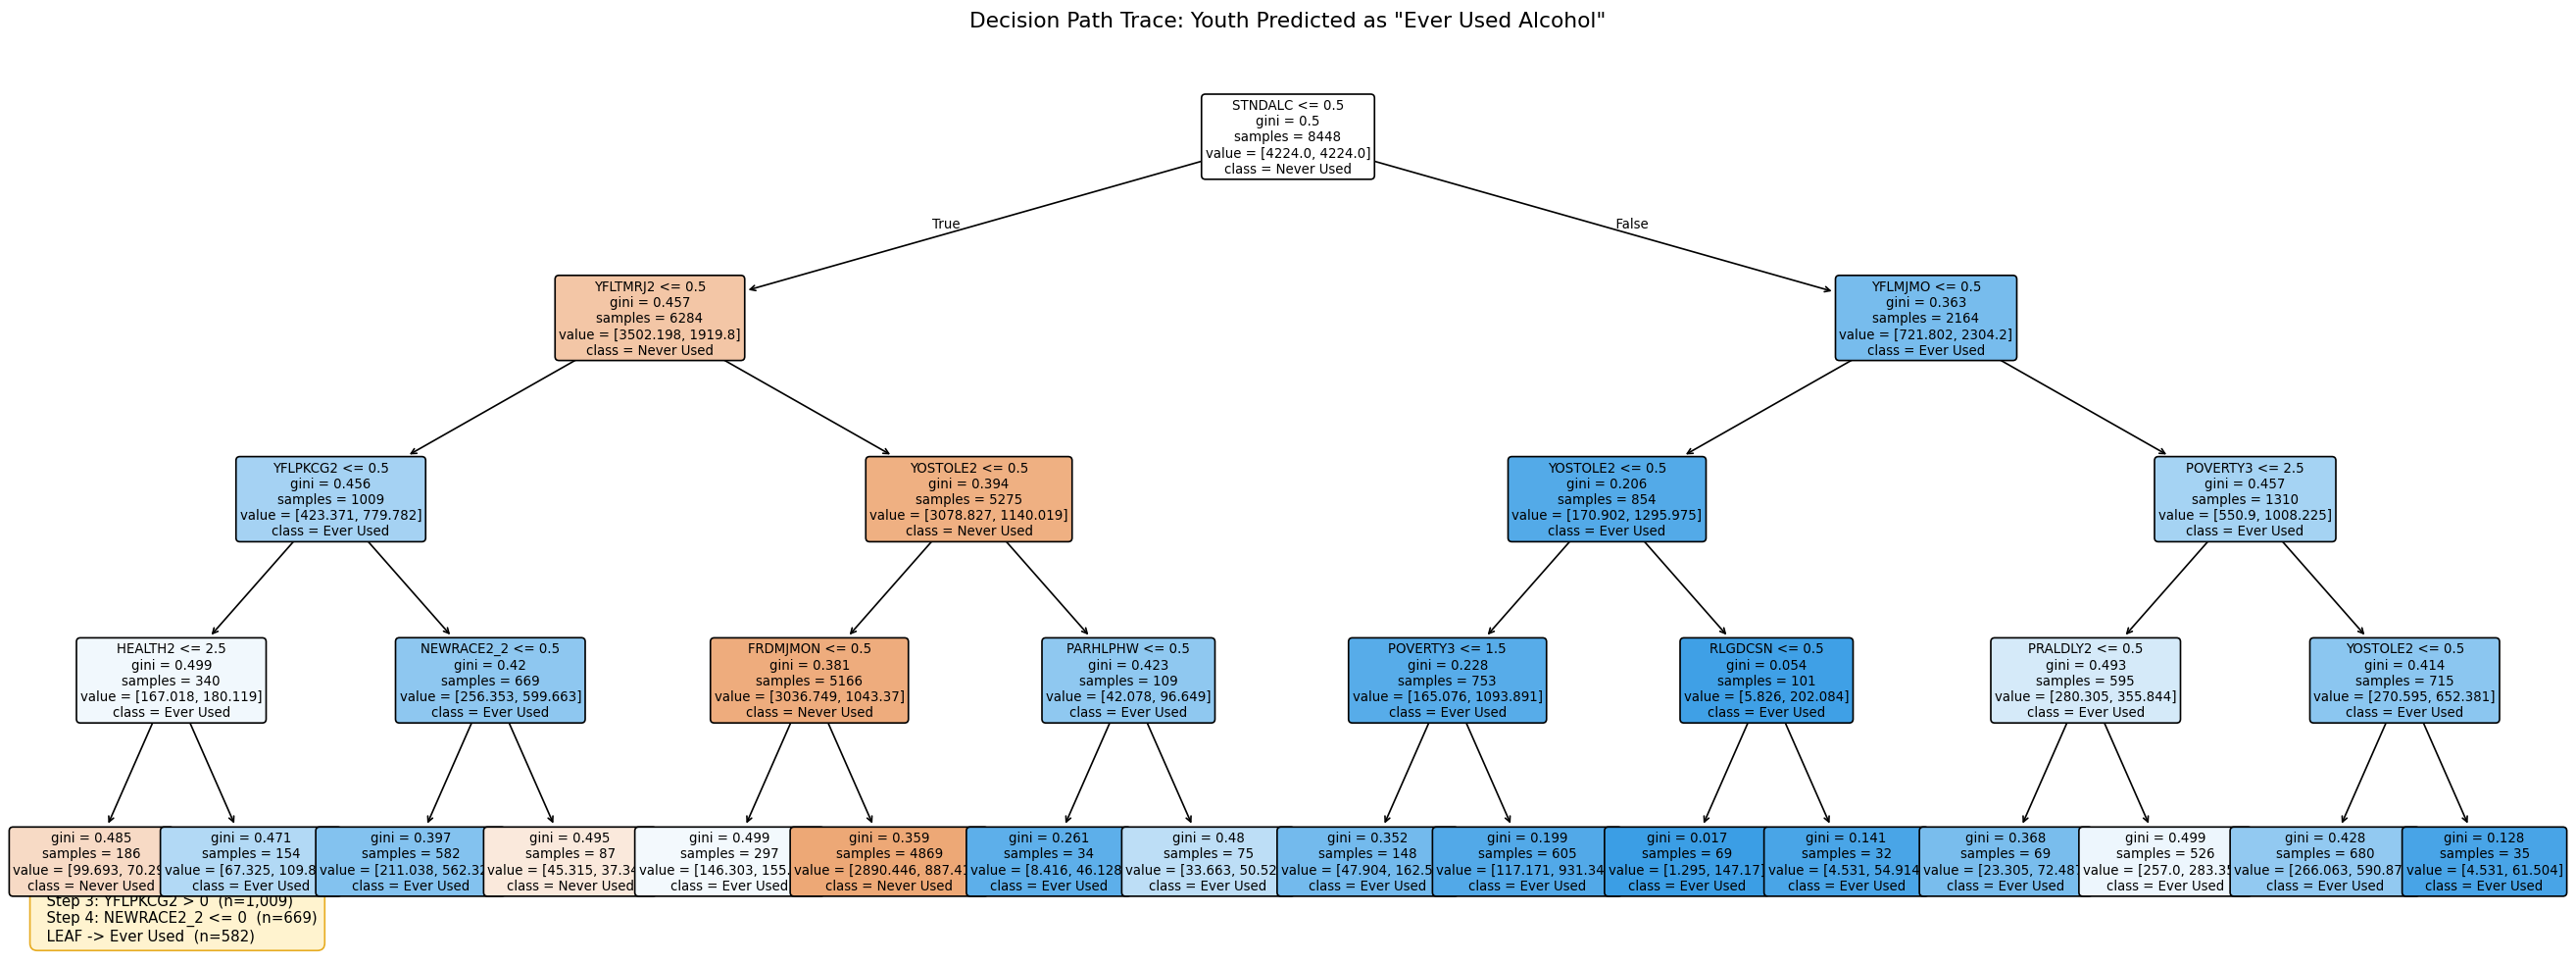

Saved: fig_path_trace.png


In [36]:
# ── Build annotated path figure ───────────────────────────────────────────────
fig_path, ax_path = plt.subplots(figsize=(28, 10))
plot_tree(
    dt_vis,
    feature_names=feature_cols,
    class_names=['Never Used', 'Ever Used'],
    filled=True, rounded=True, fontsize=8,
    ax=ax_path, impurity=True, proportion=False
)
ax_path.set_title(
    'Decision Path Trace: Youth Predicted as "Ever Used Alcohol"',
    fontsize=13, pad=12
)

# Annotate the path with a text box listing each decision step
path_lines = ['TRACED PATH (highlighted):']
for i, step in enumerate(path, 1):
    arrow = '-->'
    path_lines.append(
        f"  Step {i}: {step['feature']} {step['direction']} {step['threshold']:.0f}"
        f"  (n={step['n_samples']:,})"
    )
path_lines.append(f"  LEAF -> {'Ever Used' if leaf_class == 1 else 'Never Used'}  (n={leaf_n})")

path_text = '\n'.join(path_lines)
ax_path.text(
    0.01, 0.01, path_text,
    transform=ax_path.transAxes,
    fontsize=9, verticalalignment='bottom',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff3cd',
              edgecolor='#e6a817', alpha=0.95)
)

plt.savefig('fig_path_trace.png', dpi=140, bbox_inches='tight')
plt.show()
print("Saved: fig_path_trace.png")



## Encoding Comparison: Binary vs. Ordinal vs. Numerical

The same underlying behavior - marijuana use - is encoded three different ways
in this dataset:

| Encoding | Variable | Type | Description |
|---|---|---|---|
| Binary | `MRJFLAG` | 0/1 | Ever used marijuana (yes/no) |
| Ordinal | `MRJ3CLASS` | 0/1/2 | Never / Occasional / Frequent (our collapsed version) |
| Numerical | `IRMJFY` | 0–365 | Days per year of marijuana use |

We fit the same decision tree on the same predictors using each encoding as the target,
and compare: (1) what features become important, and (2) what each encoding can and cannot tell us.


In [37]:
# ── Prepare encoding dataset (same cleaning pipeline as main df) ──────────────
df_enc = df_raw[feature_cols_raw + ['MRJFLAG', 'MRJYDAYS', 'IRMJFY']].copy()

for col in feature_cols_raw:
    if df_enc[col].isnull().any():
        df_enc[col] = df_enc[col].fillna(df_enc[col].mode()[0])
for col in youth_exp_cols + ['IRSEX', 'IMOTHER', 'IFATHER']:
    if col in df_enc.columns and df_enc[col].max() == 2:
        df_enc[col] = df_enc[col].map({1: 1, 2: 0})

# One-hot encode nominal variables (matches main df)
df_enc = pd.get_dummies(df_enc, columns=['NEWRACE2', 'COUTYP4'],
                        drop_first=False, dtype=int)
dummy_cols_enc = sorted([c for c in df_enc.columns
                         if c.startswith('NEWRACE2_') or c.startswith('COUTYP4_')])
feature_cols_enc = [c for c in feature_cols_raw
                    if c not in ['NEWRACE2', 'COUTYP4']] + dummy_cols_enc

# Three encoding targets
y_enc_bin = df_enc['MRJFLAG']
mrj_map = {6: 0, 1: 1, 2: 1, 3: 2, 4: 2, 5: 2}
y_enc_ord = df_enc['MRJYDAYS'].map(mrj_map)
df_num = df_enc[df_enc['IRMJFY'] != 993].copy()
df_num['IRMJFY'] = df_num['IRMJFY'].replace(991, 0)
y_enc_num = df_num['IRMJFY']
X_enc_all = df_enc[feature_cols_enc]
X_enc_num = df_num[feature_cols_enc]

print("Three encoding targets (marijuana use):")
print(f"  Binary    MRJFLAG  : {dict(y_enc_bin.value_counts().sort_index())}")
print(f"  Ordinal   MRJ3CLASS: {dict(y_enc_ord.value_counts().sort_index())}")
print(f"  Numerical IRMJFY   : mean={y_enc_num.mean():.1f}  max={y_enc_num.max()}  n={len(y_enc_num):,}")
print(f"  Feature columns    : {len(feature_cols_enc)}")


Three encoding targets (marijuana use):
  Binary    MRJFLAG  : {0: np.int64(8971), 1: np.int64(1590)}
  Ordinal   MRJ3CLASS: {0: np.int64(9226), 1: np.int64(769), 2: np.int64(566)}
  Numerical IRMJFY   : mean=11.4  max=365  n=10,306
  Feature columns    : 63


In [38]:
# ── Fit one Decision Tree per encoding ────────────────────────────────────────
enc_results = {}

# 1. Binary classifier
Xtr, Xte, ytr, yte = train_test_split(
    X_enc_all, y_enc_bin, test_size=0.2, stratify=y_enc_bin, random_state=SEED)
dt_e_bin = DecisionTreeClassifier(max_depth=4, class_weight='balanced',
                                   min_samples_leaf=30, random_state=SEED)
dt_e_bin.fit(Xtr, ytr)
auc_bin = roc_auc_score(yte, dt_e_bin.predict_proba(Xte)[:, 1])
enc_results['Binary\n(MRJFLAG)'] = {
    'importances': dt_e_bin.feature_importances_,
    'metric_label': f'ROC AUC = {auc_bin:.3f}'
}
print(f"Binary   → ROC AUC : {auc_bin:.3f}")

# 2. Ordinal classifier
Xtr, Xte, ytr, yte = train_test_split(
    X_enc_all, y_enc_ord, test_size=0.2, stratify=y_enc_ord, random_state=SEED)
dt_e_ord = DecisionTreeClassifier(max_depth=4, class_weight='balanced',
                                   min_samples_leaf=30, random_state=SEED)
dt_e_ord.fit(Xtr, ytr)
from sklearn.metrics import f1_score as f1
f1_ord = f1(yte, dt_e_ord.predict(Xte), average='macro')
enc_results['Ordinal\n(MRJ3CLASS)'] = {
    'importances': dt_e_ord.feature_importances_,
    'metric_label': f'Macro F1 = {f1_ord:.3f}'
}
print(f"Ordinal  → Macro F1: {f1_ord:.3f}")

# 3. Numerical regressor
Xtr, Xte, ytr, yte = train_test_split(
    X_enc_num, y_enc_num, test_size=0.2, random_state=SEED)
dt_e_num = DecisionTreeRegressor(max_depth=4, min_samples_leaf=30, random_state=SEED)
dt_e_num.fit(Xtr, ytr)
r2_num = r2_score(yte, dt_e_num.predict(Xte))
enc_results['Numerical\n(IRMJFY days/yr)'] = {
    'importances': dt_e_num.feature_importances_,
    'metric_label': f'R² = {r2_num:.3f}'
}
print(f"Numerical → R²     : {r2_num:.3f}")


Binary   → ROC AUC : 0.858
Ordinal  → Macro F1: 0.445
Numerical → R²     : 0.246


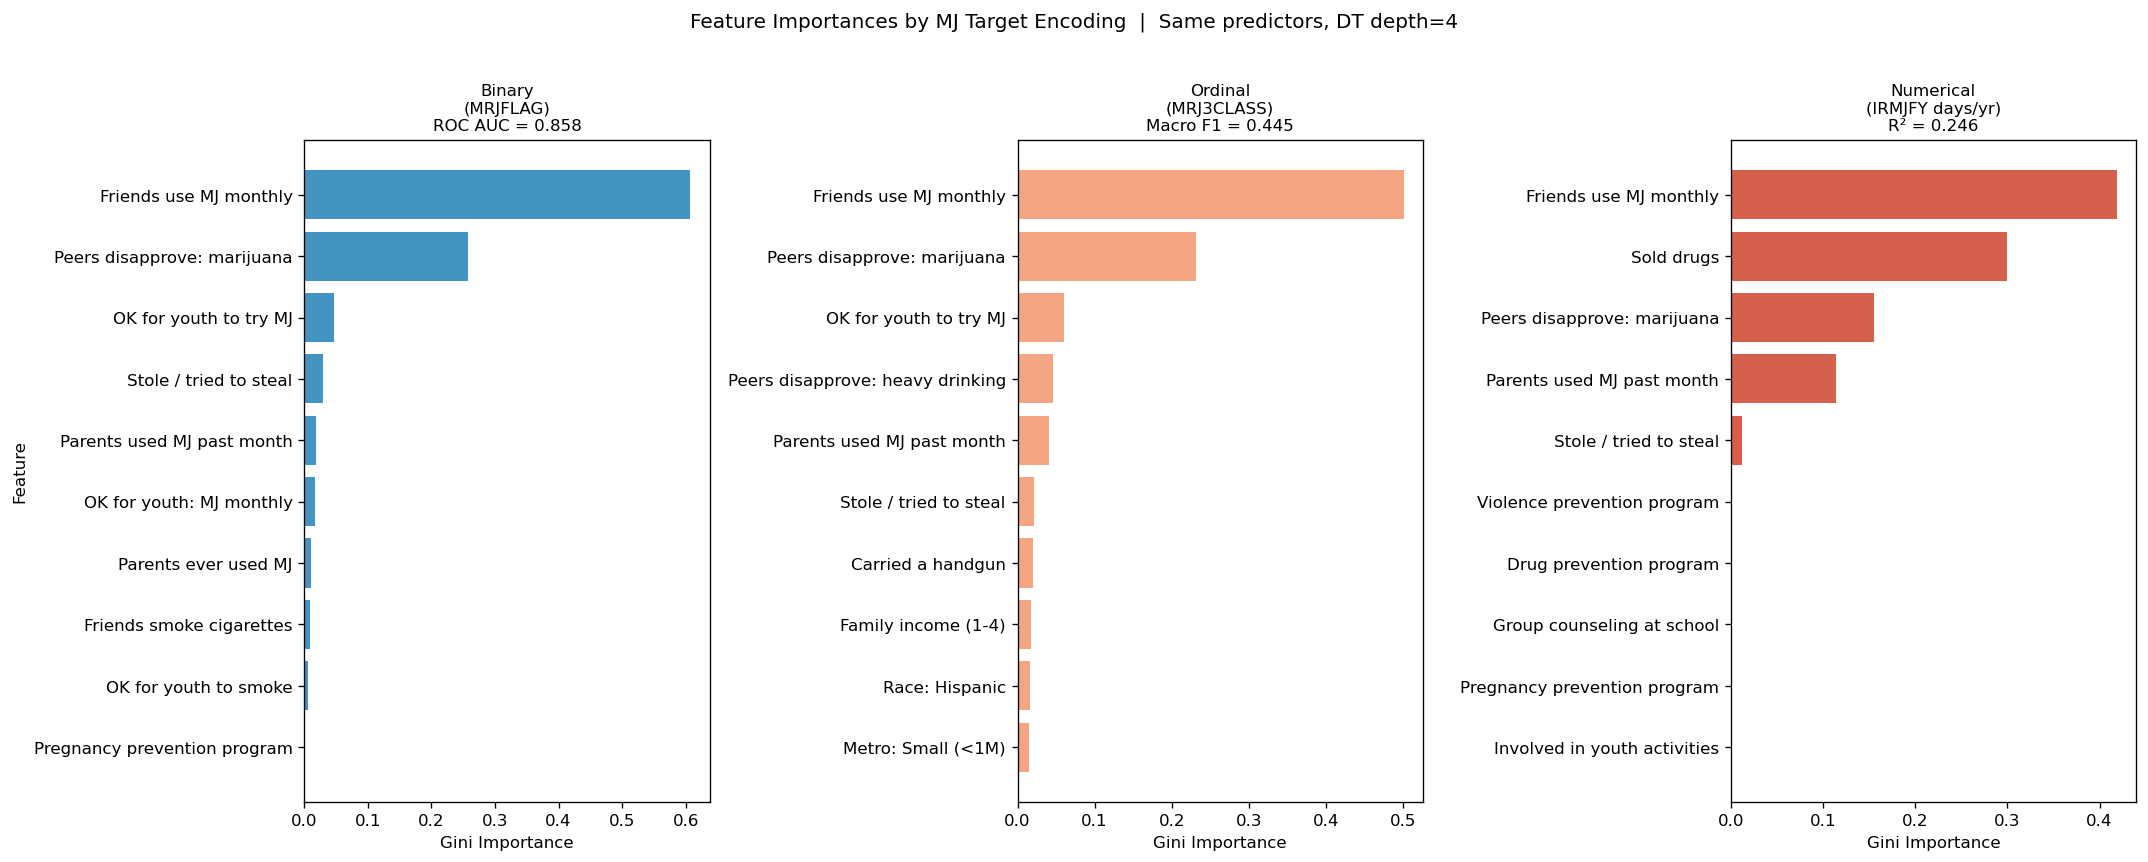

Saved: fig_encoding_comparison.png


In [39]:
# ── Side-by-side importance bar charts (readable labels) ─────────────────────
fig_enc, axes = plt.subplots(1, 3, figsize=(18, 7))
colors = ['#4393c3', '#f4a582', '#d6604d']

for ax, (enc_name, res), color in zip(axes, enc_results.items(), colors):
    imp_df = (pd.DataFrame({'feature': feature_cols_enc,
                             'importance': res['importances']})
                .sort_values('importance', ascending=False)
                .head(10).reset_index(drop=True))
    ax.barh([label(f) for f in imp_df['feature'][::-1]],
             imp_df['importance'][::-1], color=color)
    ax.set_title(f"{enc_name}\n{res['metric_label']}", fontsize=10)
    ax.set_xlabel('Gini Importance')
    if ax == axes[0]:
        ax.set_ylabel('Feature')
plt.suptitle('Feature Importances by MJ Target Encoding  |  Same predictors, DT depth=4',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig_encoding_comparison.png', dpi=140, bbox_inches='tight')
plt.show()
print("Saved: fig_encoding_comparison.png")


In [40]:
# ── Feature importance comparison table (readable labels) ────────────────────
enc_names = list(enc_results.keys())
imps = [enc_results[n]['importances'] for n in enc_names]
all_imp = {feat: tuple(v[i] for v in imps) for i, feat in enumerate(feature_cols_enc)}
top_feats = sorted(all_imp, key=lambda f: max(all_imp[f]), reverse=True)[:12]

print(f"{'Feature':<35}  {'Binary':>10}  {'Ordinal':>10}  {'Numerical':>10}")
print("-" * 70)
for feat in top_feats:
    b, o, n = all_imp[feat]
    print(f"{label(feat):<35}  {b:>10.4f}  {o:>10.4f}  {n:>10.4f}")


Feature                                  Binary     Ordinal   Numerical
----------------------------------------------------------------------
Friends use MJ monthly                   0.6072      0.5009      0.4186
Sold drugs                               0.0000      0.0000      0.3001
Peers disapprove: marijuana              0.2572      0.2321      0.1554
Parents used MJ past month               0.0180      0.0413      0.1141
OK for youth to try MJ                   0.0467      0.0601      0.0000
Peers disapprove: heavy drinking         0.0000      0.0454      0.0000
Stole / tried to steal                   0.0297      0.0208      0.0118
Carried a handgun                        0.0000      0.0197      0.0000
Family income (1-4)                      0.0000      0.0176      0.0000
OK for youth: MJ monthly                 0.0169      0.0000      0.0000
Race: Hispanic                           0.0000      0.0155      0.0000
Metro: Small (<1M)                       0.0000      0.0155      


## Discussion Notes

### Key findings
- Most important predictor across problems: `STNDALC`, whether peers disapprove of alcohol.
  This social-norm variable accounts for the majority of information gain in single trees.
- Attitude toward a different substance as a predictor: `YFLTMRJ2` (thinks it's OK for youth
  to try marijuana) is the second-strongest predictor of alcohol use, suggesting that general
  permissive attitudes toward substances cluster together.
- Parent behavior matters: `PRALDLY2` (parents drink daily) and `PRMJEVR2` (parents ever used MJ)
  appear in deeper branches - parental modeling has signal even after controlling for peer norms.

### Binary vs. ordinal vs. numerical encoding
The same underlying behavior (e.g., marijuana use) is coded three ways in this dataset:
- `MRJFLAG` — binary (ever/never)
- `MRJ3CLASS` / `MRJYDAYS` — ordinal (never/occasional/frequent)
- `IRMJFY` — numerical (days per year)

Binary trees split cleanest on the binary flag; they lose frequency information.
Ordinal models can distinguish occasional from chronic use, which has very different
policy implications. Numerical regression captures dose-response relationships but
is sensitive to the heavy zero-inflation (most youth have 0 days).

### Model comparison take-aways
- Single DTs are interpretable but high-variance; ensemble methods consistently
  improve AUC/RMSE.
- Random Forest outperforms AdaBoost on the binary task because the class imbalance
  is handled by `class_weight='balanced'`.
- Gradient Boosting is the strongest overall but slowest to tune.
- Regression R² values are low (~0.072–0.120), which are expected given the zero-inflation
  and the noisy self-report nature of survey data.

### Ethical considerations
- These models identify correlates, not causes. A feature being "important" in a
  tree does not mean intervention on that feature will change outcomes.
- Peer and parent drug use are among the top predictors - flagging individual youth
  based on family behavior raises fairness and privacy concerns.
- Race and income appear in the demographic features; care is needed to avoid
  building tools that encode socioeconomic disadvantage as a risk score.



## References

[1] Substance Abuse and Mental Health Services Administration (SAMHSA). National Survey on Drug Use and Health (NSDUH), 2019. U.S. Department of Health and Human Services. https://www.datafiles.samhsa.gov

[2] Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., … Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830. https://jmlr.org/papers/v12/pedregosa11a.html

[3] Breiman, L. (2001). Random forests. Machine Learning, 45(1), 5–32. https://doi.org/10.1023/A:1010933404324

[4] Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. The Annals of Statistics, 29(5), 1189–1232. https://doi.org/10.1214/aos/1013203451

[5] Freund, Y., & Schapire, R. E. (1997). A decision-theoretic generalization of on-line learning and an application to boosting. Journal of Computer and System Sciences, 55(1), 119–139. https://doi.org/10.1006/jcss.1997.1504